## Libraries

In [62]:
import os
import glob
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import cv2
import random
from pathlib import Path
from PIL import Image, ImageEnhance 
from tqdm import tqdm
import shutil
import math
import re
from collections import Counter, defaultdict
import pandas as pd

print("Done.")

Done.


## Path to NEU-DET Dataset

In [2]:
img_dir = "./NEU_DET_YOLO_Ready/images/val"
ann_dir = "./NEU_DET_YOLO_Ready/labels/val"

print("Done.")

Done.


## 1. Original Validation Split Analysis

large bbox threshold: > 9927.00 pixels^2
scattered threshold: > 108.37 mean pixel distance

classes with mostly large bboxes:
pitted: 73.3%
crazing: 48.8%
rolled-in: 29.5%
patches: 8.7%
scratches: 2.4%
inclusion: 0.0%

classes with mostly scattered bboxes:
patches: 50.0%
rolled-in: 18.3%
inclusion: 16.7%
crazing: 13.3%
scratches: 11.7%
pitted: 8.3%


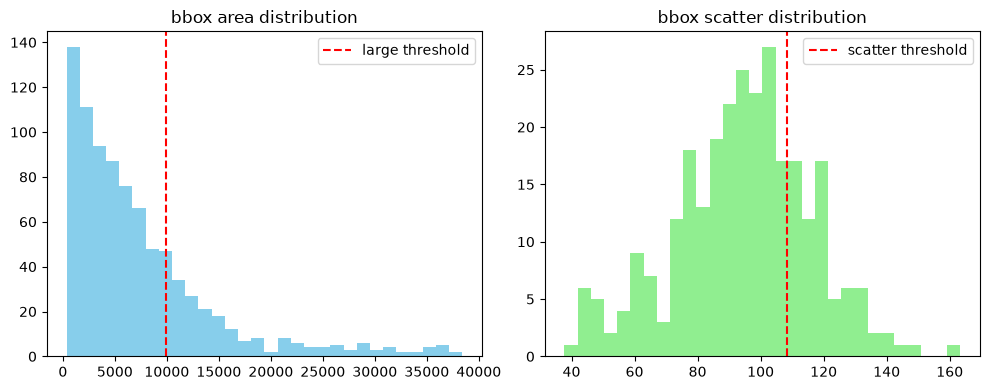

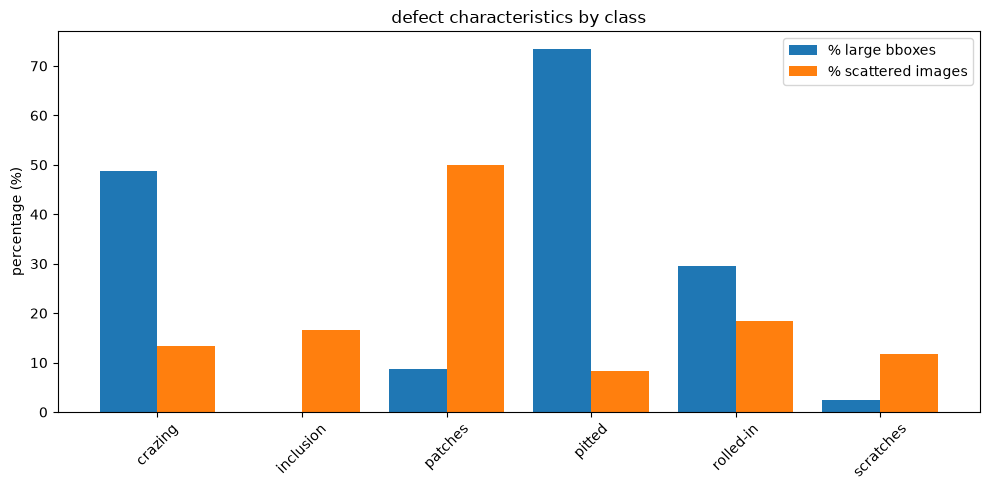

In [4]:
output_1 = Path("./Analysis_of_OriginalVal")
output_1.mkdir(exist_ok=True)

# init data storage
areas, scatters = [], []
b_classes, i_classes = [], []

# loop through annotations
for filepath in glob.glob(os.path.join(ann_dir, "*.*")):
    fname = os.path.basename(filepath)
    if not (fname.endswith('.xml') or fname.endswith('.txt')): 
        continue
    
    # extract class from filename
    c_name = fname.split('_')[0]
    centers, img_areas = [], []
    
    # parse xml
    if fname.endswith('.xml'):
        root = ET.parse(filepath).getroot()
        for obj in root.findall('object'):
            bbox = obj.find('bndbox')
            xmin, ymin = float(bbox.find('xmin').text), float(bbox.find('ymin').text)
            xmax, ymax = float(bbox.find('xmax').text), float(bbox.find('ymax').text)
            img_areas.append((xmax - xmin) * (ymax - ymin))
            centers.append(((xmin + xmax) / 2, (ymin + ymax) / 2))
            
    # parse yolo txt
    elif fname.endswith('.txt'):
        with open(filepath, 'r') as f:
            for line in f:
                p = line.strip().split()
                if len(p) >= 5:
                    w, h = float(p[3]) * 200, float(p[4]) * 200
                    img_areas.append(w * h)
                    centers.append((float(p[1]) * 200, float(p[2]) * 200))
                    
    areas.extend(img_areas)
    b_classes.extend([c_name] * len(img_areas))
    
    # calc mean distance for scatter
    if len(centers) > 1:
        dists = [np.hypot(c1[0]-c2[0], c1[1]-c2[1]) for c1, c2 in combinations(centers, 2)]
        scatters.append(np.mean(dists))
    else:
        scatters.append(0.0)
    i_classes.append(c_name)

# define thresholds at 75th percentile
large_th = np.percentile(areas, 75)
scatter_th = np.percentile([s for s in scatters if s > 0], 75)

print(f"large bbox threshold: > {large_th:.2f} pixels^2")
print(f"scattered threshold: > {scatter_th:.2f} mean pixel distance")

# get unique classes
u_classes = sorted(list(set(i_classes)))

# calc class distributions
large_pct = {c: sum((a > large_th) and (bc == c) for a, bc in zip(areas, b_classes)) / max(1, b_classes.count(c)) * 100 for c in u_classes}
scatter_pct = {c: sum((s > scatter_th) and (ic == c) for s, ic in zip(scatters, i_classes)) / max(1, i_classes.count(c)) * 100 for c in u_classes}

print("\nclasses with mostly large bboxes:")
for c, pct in sorted(large_pct.items(), key=lambda x: -x[1]): 
    print(f"{c}: {pct:.1f}%")

print("\nclasses with mostly scattered bboxes:")
for c, pct in sorted(scatter_pct.items(), key=lambda x: -x[1]): 
    print(f"{c}: {pct:.1f}%")

# plot histograms
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(areas, bins=30, color='skyblue')
plt.axvline(large_th, color='r', linestyle='dashed', label='large threshold')
plt.title('bbox area distribution')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist([s for s in scatters if s > 0], bins=30, color='lightgreen')
plt.axvline(scatter_th, color='r', linestyle='dashed', label='scatter threshold')
plt.title('bbox scatter distribution')
plt.legend()
plt.tight_layout()
plt.savefig(output_1 / "bbox_distribution.png")

# plot metrics per class
plt.figure(figsize=(10, 5))
x = np.arange(len(u_classes))
plt.bar(x - 0.2, [large_pct[c] for c in u_classes], 0.4, label='% large bboxes')
plt.bar(x + 0.2, [scatter_pct[c] for c in u_classes], 0.4, label='% scattered images')
plt.xticks(x, u_classes, rotation=45)
plt.ylabel('percentage (%)')
plt.title('defect characteristics by class')
plt.legend()
plt.tight_layout()
plt.savefig(output_1 / "characteristic_by_class.png")

## 2. Extracting Defect-free Images from the Background Regions
1. $130 \times 130$ sliding window with stride of 10.
2. filtering windows that include intersection with bbox area

In [6]:
def process_sliding_window_patches(
    img_dir: str, 
    label_dir: str, 
    output_dir: str,
    window_size: int = 100,
    stride: int = 1,
    target_size: tuple = (200, 200)
):
    # init paths
    images_path = Path(img_dir)
    labels_path = Path(label_dir)
    out_path = Path(output_dir)

    # create output dir
    out_path.mkdir(parents=True, exist_ok=True)

    # image extensions
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
    image_files = [f for f in images_path.iterdir() if f.suffix.lower() in valid_extensions]

    # counters
    total_saved = 0
    print(f"Processing {len(image_files)} images using {window_size}x{window_size} sliding window (stride={stride})...")

    for img_file in tqdm(image_files):
        # load grayscale
        img = Image.open(img_file).convert('L')
        img_w, img_h = img.size

        # skip small images
        if img_w < window_size or img_h < window_size:
            continue

        # binary obstacle mask (0=bg, 1=defect)
        obstacle_mask = np.zeros((img_h, img_w), dtype=np.uint8)

        # read label file
        txt_file = labels_path / img_file.with_suffix('.txt').name

        if txt_file.exists():
            with open(txt_file, 'r') as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    parts = line.split()
                    x_center, y_center, w, h = map(float, parts[1:])

                    # yolo to pixel coords
                    box_w = w * img_w
                    box_h = h * img_h
                    xmin = int((x_center - (w / 2)) * img_w)
                    ymin = int((y_center - (h / 2)) * img_h)
                    xmax = int(xmin + box_w)
                    ymax = int(ymin + box_h)

                    # mark obstacle
                    x0, x1 = max(0, xmin), min(img_w, xmax)
                    y0, y1 = max(0, ymin), min(img_h, ymax)
                    obstacle_mask[y0:y1, x0:x1] = 1

        # integral image for o(1) overlap checks
        integral_mask = np.pad(np.cumsum(np.cumsum(obstacle_mask, axis=0), axis=1), ((1, 0), (1, 0)))

        patch_idx = 0
        img_stem = img_file.stem

        # slide window
        for y in range(0, img_h - window_size + 1, stride):
            for x in range(0, img_w - window_size + 1, stride):
                
                # fast sum via integral image
                y2, x2 = y + window_size, x + window_size
                obstacle_count = integral_mask[y2, x2] - integral_mask[y, x2] - integral_mask[y2, x] + integral_mask[y, x]

                # clean window (no defect overlap)
                if obstacle_count == 0:
                    crop_box = (x, y, x + window_size, y + window_size)
                    patch = img.crop(crop_box)

                    # upsample to target size
                    upscaled_patch = patch.resize(target_size, Image.Resampling.BICUBIC)

                    # save patch
                    save_name = f"{img_stem}_x{x}_y{y}_clean.jpg"
                    upscaled_patch.save(out_path / save_name)

                    patch_idx += 1
                    total_saved += 1

    # summary
    print(f"\nProcessing complete!")
    print(f"Total clean patches extracted: {total_saved}")
    print(f"Output saved to: {out_path.resolve()}")

# main 
IMG_DIR = r"NEU_DET_YOLO_Ready\images\val"
LABEL_DIR = r"NEU_DET_YOLO_Ready\labels\val"
OUTPUT_DIR = r"NEU_DET_YOLO_Ready\extracted_imgs"

process_sliding_window_patches(
    img_dir=IMG_DIR,
    label_dir=LABEL_DIR,
    output_dir=OUTPUT_DIR,
    window_size=100,
    stride=10,
    target_size=(200, 200)
)

Processing 360 images using 100x100 sliding window (stride=10)...


  0%|          | 0/360 [00:00<?, ?it/s]C:\Users\acer\AppData\Local\Temp\ipykernel_13064\3049059947.py:74: RuntimeWarning: overflow encountered in scalar subtract
  obstacle_count = integral_mask[y2, x2] - integral_mask[y, x2] - integral_mask[y2, x] + integral_mask[y, x]
C:\Users\acer\AppData\Local\Temp\ipykernel_13064\3049059947.py:74: RuntimeWarning: overflow encountered in scalar add
  obstacle_count = integral_mask[y2, x2] - integral_mask[y, x2] - integral_mask[y2, x] + integral_mask[y, x]
100%|██████████| 360/360 [00:02<00:00, 175.31it/s]


Processing complete!
Total clean patches extracted: 2861
Output saved to: C:\Users\acer\Desktop\DataAugmentation\NEU_DET_YOLO_Ready\extracted_imgs


## 3. Analyzing & Comparing Stats
#### _excluding bbox pixels from calculations_
1. avg brightness & contrast: binary mask that assigns 0 to bboxes & 1 to background, restricting calculations to background (mask == 1)
2. plotting histogram diagram 



[ANALYSIS 1: BRIGHTNESS & CONTRAST]
   Validation (BG Only): Mean = 131.89, Std Dev = 34.88
   Extracted Dataset:    Mean = 106.94, Std Dev = 17.38
   Absolute Deviation:   Mean Delta = 24.95, Std Dev Delta = 17.50
------------------------------------------------------------
[ANALYSIS 2: INTENSITY HISTOGRAM DISTRIBUTION]
   Validation (BG Only): Peak Bin = 255
                         Dark (0-84) = 20.2%, Mid (85-169) = 55.7%, Bright (170-255) = 24.1%
   Extracted Dataset:    Peak Bin = 83
                         Dark (0-84) = 34.1%, Mid (85-169) = 56.9%, Bright (170-255) = 8.9%
------------------------------------------------------------


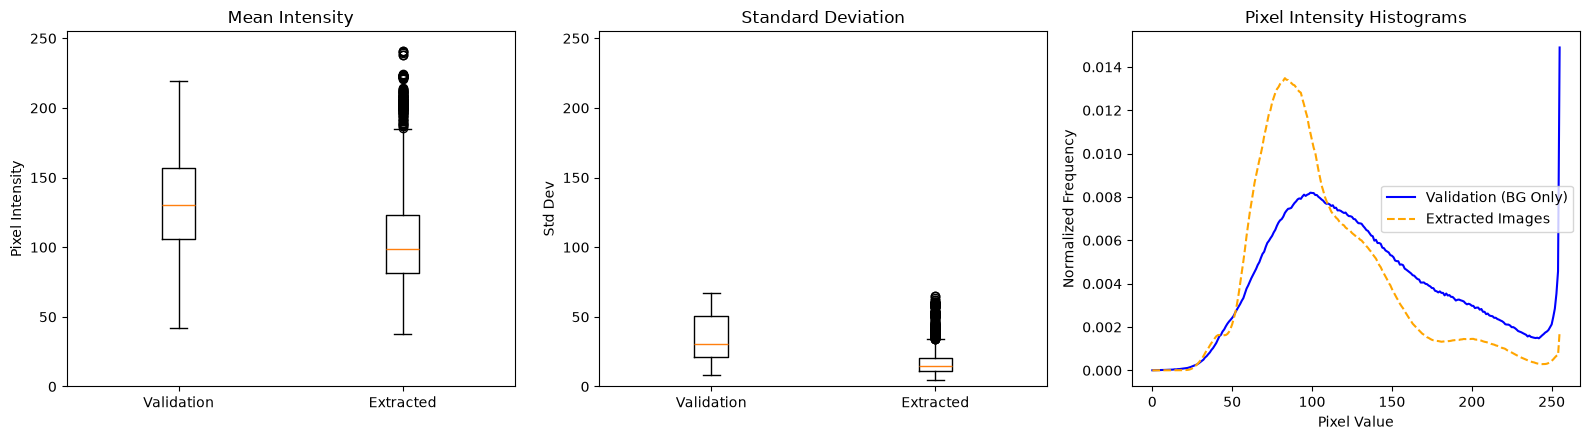

In [ ]:
# path
ext_dir = Path("./NEU_DET_YOLO_Ready/extracted_imgs")
img_dir = Path("./NEU_DET_YOLO_Ready/images/val")
ann_dir = Path("./NEU_DET_YOLO_Ready/labels/val")

# output paths
output_4 = Path("./ComparisonResults")
output_4.mkdir(exist_ok=True)

# find only jpg image files
val_img_paths = sorted(list(img_dir.glob("*.jpg")))
extracted_img_paths = sorted(list(ext_dir.glob("*.jpg")))

# initialize empty lists
val_means, val_stds = [], []
extracted_means, extracted_stds = [], []
val_hists, extracted_hists = [], []

# parse yolo format normalized coordinates
def get_defect_boxes_yolo(txt_path, img_w, img_h):
    boxes = []
    if not txt_path.exists():
        return boxes
    with open(txt_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            _, x_c, y_c, w, h = map(float, parts)
            xmin = int((x_c - w / 2) * img_w)
            ymin = int((y_c - h / 2) * img_h)
            xmax = int((x_c + w / 2) * img_w)
            ymax = int((y_c + h / 2) * img_h)
            boxes.append((xmin, ymin, xmax, ymax))
    return boxes

# process validation images with yolo annotations
for img_path in val_img_paths:
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    h, w = img.shape
    
    # generate background mask
    mask = np.ones((h, w), dtype=np.uint8)
    txt_path = ann_dir / f"{img_path.stem}.txt"
    boxes = get_defect_boxes_yolo(txt_path, w, h)
    
    for xmin, ymin, xmax, ymax in boxes:
        xmin, xmax = max(0, xmin), min(w, xmax)
        ymin, ymax = max(0, ymin), min(h, ymax)
        mask[ymin:ymax, xmin:xmax] = 0
        
    bg_pixels = img[mask == 1]
    if len(bg_pixels) == 0:
        continue
        
    val_means.append(np.mean(bg_pixels))
    val_stds.append(np.std(bg_pixels))
    
    # normalize histogram to sum to 1.0
    hist, _ = np.histogram(bg_pixels, bins=256, range=(0, 256))
    hist_norm = hist / np.sum(hist) if np.sum(hist) > 0 else np.zeros(256)
    val_hists.append(hist_norm)

# process extracted background images
for img_path in extracted_img_paths:
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    extracted_means.append(np.mean(img))
    extracted_stds.append(np.std(img))
    
    # normalize histogram to sum to 1.0
    hist, _ = np.histogram(img, bins=256, range=(0, 256))
    hist_norm = hist / np.sum(hist) if np.sum(hist) > 0 else np.zeros(256)
    extracted_hists.append(hist_norm)

# numerical computations for validation
val_mean_avg = np.mean(val_means) if val_means else 0.0
val_std_avg = np.mean(val_stds) if val_stds else 0.0
val_hist_avg = np.mean(val_hists, axis=0) if val_hists else np.zeros(256)

# numerical computations for extracted
ext_mean_avg = np.mean(extracted_means) if extracted_means else 0.0
ext_std_avg = np.mean(extracted_stds) if extracted_stds else 0.0
ext_hist_avg = np.mean(extracted_hists, axis=0) if extracted_hists else np.zeros(256)

# 1. print brightness & contrast metrics
print("[ANALYSIS 1: BRIGHTNESS & CONTRAST]")
print(f"   Validation (BG Only): Mean = {val_mean_avg:.2f}, Std Dev = {val_std_avg:.2f}")
print(f"   Extracted Dataset:    Mean = {ext_mean_avg:.2f}, Std Dev = {ext_std_avg:.2f}")
print(f"   Absolute Deviation:   Mean Delta = {abs(val_mean_avg - ext_mean_avg):.2f}, Std Dev Delta = {abs(val_std_avg - ext_std_avg):.2f}")
print("-" * 60)

# 2. print intensity histogram metrics (already normalized, sum is 1.0)
val_dark_pct = np.sum(val_hist_avg[:85]) * 100
val_mid_pct = np.sum(val_hist_avg[85:170]) * 100
val_bright_pct = np.sum(val_hist_avg[170:]) * 100

ext_dark_pct = np.sum(ext_hist_avg[:85]) * 100
ext_mid_pct = np.sum(ext_hist_avg[85:170]) * 100
ext_bright_pct = np.sum(ext_hist_avg[170:]) * 100

print("[ANALYSIS 2: INTENSITY HISTOGRAM DISTRIBUTION]")
print(f"   Validation (BG Only): Peak Bin = {np.argmax(val_hist_avg)}")
print(f"                         Dark (0-84) = {val_dark_pct:.1f}%, Mid (85-169) = {val_mid_pct:.1f}%, Bright (170-255) = {val_bright_pct:.1f}%")
print(f"   Extracted Dataset:    Peak Bin = {np.argmax(ext_hist_avg)}")
print(f"                         Dark (0-84) = {ext_dark_pct:.1f}%, Mid (85-169) = {ext_mid_pct:.1f}%, Bright (170-255) = {ext_bright_pct:.1f}%")
print("-" * 60)

# generate three-panel diagram layout (2 boxplots + 1 histogram)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# diagram 1: mean intensity boxplot
axes[0].boxplot([val_means, extracted_means])
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(['Validation', 'Extracted'])
axes[0].set_title('Mean Intensity')
axes[0].set_ylabel('Pixel Intensity')
axes[0].set_ylim(0, 255)

# diagram 2: standard deviation boxplot
axes[1].boxplot([val_stds, extracted_stds])
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['Validation', 'Extracted'])
axes[1].set_title('Standard Deviation')
axes[1].set_ylabel('Std Dev')
axes[1].set_ylim(0, 255)

# diagram 3: intensity histogram comparison
axes[2].plot(val_hist_avg, label="Validation (BG Only)", color="blue")
axes[2].plot(ext_hist_avg, label="Extracted Images", color="orange", linestyle="--")
axes[2].set_title("Pixel Intensity Histograms")
axes[2].set_xlabel("Pixel Value")
axes[2].set_ylabel("Normalized Frequency")
axes[2].legend()

plt.tight_layout()
plt.savefig(output_4 / "results.png", dpi=150)
plt.show()

## _Rename images "clean-index"_

In [17]:
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

image_files = sorted([
    f for f in ext_dir.iterdir() 
    if f.is_file() and f.suffix.lower() in valid_extensions
])

print(f"Found {len(image_files)} images to rename.")

# temp
temp_files = []
for i, file_path in enumerate(image_files):
    temp_name = file_path.parent / f"__temp_{i}{file_path.suffix.lower()}"
    file_path.rename(temp_name)
    temp_files.append(temp_name)

# final format
for i, temp_path in enumerate(temp_files):
    final_name = temp_path.parent / f"clean_{i}{temp_path.suffix}"
    temp_path.rename(final_name)

print("Renaming completed successfully!")

Found 2861 images to rename.
Renaming completed successfully!


## 4. Merging
#### Method (A): two-state Markov chain
1. frames are in one of these two states: 
    1. extracted defect-free images (2861)
    2. existing defected images (360)
2. two fixed probabilities control how long the frames stay in each state
    1. probability of the next frame being defect-free = 0.98
    2. probability of the next frame being defected = 0.7
3. starts in the defect-free state, draws images from both directories, switches states based on the defined probabilities.
4. if all images in each of the directories have been picked, the state is forced to switch and stay in the other state as long as it still has images.
5. renaming defected images to frameIndex_defectClass & defect-free images to frameIndex_clean

In [ ]:
# source dirs
defected_img_dir = "NEU_DET_YOLO_Ready/images/val"
defected_lbl_dir = "NEU_DET_YOLO_Ready/labels/val"
ext_dir = "NEU_DET_YOLO_Ready/extracted_imgs"

# target dirs
output_img_dir = "MarkovChain/images/val"
output_lbl_dir = "MarkovChain/labels/val"

os.makedirs(output_img_dir, exist_ok=True)
os.makedirs(output_lbl_dir, exist_ok=True)

class_mapping = {
    0: "crazing",
    1: "inclusion",
    2: "patches",
    3: "pitted_surface",
    4: "rolled_in_scale",
    5: "scratches"
}

# gather & shuffle pools
defect_images = sorted([f for f in os.listdir(defected_img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
clean_images = sorted([f for f in os.listdir(ext_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

random.seed(42)  
random.shuffle(defect_images)
random.shuffle(clean_images)

# mutable queues
defect_pool = list(defect_images)
clean_pool = list(clean_images)

merged_sequence = []

# state machine params
PROB_STAY_CLEAN = 0.98
PROB_STAY_DEFECT = 0.70

# init state
current_state = 'clean'

# generate sequence via markov switching
while len(defect_pool) > 0 or len(clean_pool) > 0:
    if current_state == 'clean':
        if len(clean_pool) > 0:
            merged_sequence.append(('clean', clean_pool.pop(0)))
            if random.random() > PROB_STAY_CLEAN and len(defect_pool) > 0:
                current_state = 'defect'
        elif len(defect_pool) > 0:
            # no clean left, switch to defect without emitting
            current_state = 'defect'
        else:
            break
                
    elif current_state == 'defect':
        if len(defect_pool) > 0:
            merged_sequence.append(('defect', defect_pool.pop(0)))
            if random.random() > PROB_STAY_DEFECT and len(clean_pool) > 0:
                current_state = 'clean'
        elif len(clean_pool) > 0:
            # no defect left, switch to clean without emitting
            current_state = 'clean'
        else:
            break

# copy files with descriptive naming
print(f"generating sequence of {len(merged_sequence)} frames...")

for sequence_number, (frame_type, img_name) in enumerate(merged_sequence):
    ext = os.path.splitext(img_name)[1]
    base_frame_name = f"frame{sequence_number:04d}"
    
    if frame_type == 'defect':
        lbl_name = os.path.splitext(img_name)[0] + ".txt"
        src_lbl_path = os.path.join(defected_lbl_dir, lbl_name)
        defect_suffix = "unknown_defect"
        
        if os.path.exists(src_lbl_path) and os.path.getsize(src_lbl_path) > 0:
            with open(src_lbl_path, 'r') as f:
                first_line = f.readline().strip()
                if first_line:
                    class_id = int(first_line.split()[0])
                    defect_suffix = class_mapping.get(class_id, "defect")
        
        new_img_name = f"{base_frame_name}_{defect_suffix}{ext}"
        new_lbl_name = f"{base_frame_name}_{defect_suffix}.txt"
        
        shutil.copy(os.path.join(defected_img_dir, img_name), os.path.join(output_img_dir, new_img_name))
        if os.path.exists(src_lbl_path):
            shutil.copy(src_lbl_path, os.path.join(output_lbl_dir, new_lbl_name))
            
    elif frame_type == 'clean':
        new_img_name = f"{base_frame_name}_clean{ext}"
        new_lbl_name = f"{base_frame_name}_clean.txt"
        
        shutil.copy(os.path.join(ext_dir, img_name), os.path.join(output_img_dir, new_img_name))
        with open(os.path.join(output_lbl_dir, new_lbl_name), 'w') as f:
            pass

print("dataset merged using markov chain.")

generating sequence of 3221 frames...
dataset merged using markov chain.


#### method (B): Markov chain + refinements
1. switches back to defect-free after 10 consecutive defected images (MAX_DEFECT RUN)
2. even when the state is defect, there is a 0.15 probability that the next frame is defect-free. so even in faulty periods there might be a defect-free frame (DEFECT_FRAME_PROB)
3. groups defects by class, once a certain defect-class appears, there is a probability of 0.85 that the next frame is also of the same class

In [31]:
defected_img_dir = "NEU_DET_YOLO_Ready/images/val"
defected_lbl_dir = "NEU_DET_YOLO_Ready/labels/val"
clean_img_dir = "NEU_DET_YOLO_Ready/extracted_imgs"

output_img_dir = "RefinedMarkovChain/images/val"
output_lbl_dir = "RefinedMarkovChain/labels/val"

os.makedirs(output_img_dir, exist_ok=True)
os.makedirs(output_lbl_dir, exist_ok=True)

class_mapping = {
    0: "crazing",
    1: "inclusion",
    2: "patches",
    3: "pitted_surface",
    4: "rolled_in_scale",    # FIXED: hyphen -> underscore
    5: "scratches"
}

# parameters
PROB_STAY_CLEAN = 0.985
PROB_STAY_DEFECT = 0.75
MAX_DEFECT_RUN = 10
DEFECT_FRAME_PROB = 0.85
DEFECT_TYPE_PERSISTENCE = 0.85

# gather source pools
defect_images = sorted([f for f in os.listdir(defected_img_dir) 
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
clean_images = sorted([f for f in os.listdir(clean_img_dir) 
                       if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

random.seed(42)
random.shuffle(defect_images)
random.shuffle(clean_images)

# group defects by class
defect_by_class = {cls: [] for cls in class_mapping.keys()}
remaining_defects = []

for img_name in defect_images:
    lbl_name = os.path.splitext(img_name)[0] + ".txt"
    src_lbl_path = os.path.join(defected_lbl_dir, lbl_name)
    cls_id = None
    
    if os.path.exists(src_lbl_path) and os.path.getsize(src_lbl_path) > 0:
        with open(src_lbl_path, 'r') as f:
            first_line = f.readline().strip()
            if first_line:
                cls_id = int(first_line.split()[0])
    
    if cls_id is not None:
        defect_by_class[cls_id].append(img_name)
    else:
        remaining_defects.append(img_name)

# flatten pool with class info
defect_pool = []
for cls in sorted(defect_by_class.keys()):
    random.shuffle(defect_by_class[cls])
    defect_pool.extend([(img, cls) for img in defect_by_class[cls]])
random.shuffle(remaining_defects)
defect_pool.extend([(img, None) for img in remaining_defects])

clean_pool = list(clean_images)

merged_sequence = []
current_state = 'clean'
current_defect_run = 0
last_defect_class = None

while len(defect_pool) > 0 or len(clean_pool) > 0:
    
    if current_state == 'clean':
        if len(clean_pool) > 0:
            merged_sequence.append(('clean', clean_pool.pop(0)))
            if random.random() > PROB_STAY_CLEAN and len(defect_pool) > 0:
                current_state = 'defect'
                current_defect_run = 0
        elif len(defect_pool) > 0:
            # no clean left, force defect
            current_state = 'defect'
            current_defect_run = 0
        else:
            break
            
    elif current_state == 'defect':
        current_defect_run += 1
        
        # force transition after max run
        force_clean = (current_defect_run >= MAX_DEFECT_RUN)
        
        # defect state may have clean frames
        is_actually_defect = (random.random() < DEFECT_FRAME_PROB)
        
        emitted = False
        
        if is_actually_defect and len(defect_pool) > 0:
            # prefer same defect class
            if last_defect_class is not None and random.random() < DEFECT_TYPE_PERSISTENCE:
                same_class_idx = None
                for i, (img, cls) in enumerate(defect_pool):
                    if cls == last_defect_class:
                        same_class_idx = i
                        break
                
                if same_class_idx is not None:
                    img_name, cls = defect_pool.pop(same_class_idx)
                else:
                    img_name, cls = defect_pool.pop(0)
            else:
                img_name, cls = defect_pool.pop(0)
            
            merged_sequence.append(('defect', img_name, cls))
            last_defect_class = cls
            emitted = True
        
        elif len(clean_pool) > 0:
            # clean frame within defect run
            merged_sequence.append(('clean', clean_pool.pop(0)))
            emitted = True
        
        # ensure progress if nothing emitted
        if not emitted and len(defect_pool) > 0:
            img_name, cls = defect_pool.pop(0)
            merged_sequence.append(('defect', img_name, cls))
            last_defect_class = cls
            emitted = True
        
        # exit
        if not emitted:
            break
        
        # state transition
        if force_clean:
            current_state = 'clean'
            current_defect_run = 0
            last_defect_class = None
        elif random.random() > PROB_STAY_DEFECT and len(clean_pool) > 0:
            current_state = 'clean'
            current_defect_run = 0
            last_defect_class = None

# copy & rename
print(f"generating enhanced sequence of {len(merged_sequence)} frames...")

for sequence_number, item in enumerate(merged_sequence):
    base_frame_name = f"frame{sequence_number:04d}"
    
    if item[0] == 'defect':
        img_name = item[1]
        cls = item[2] if len(item) > 2 else None
        ext = os.path.splitext(img_name)[1]
        
        lbl_name = os.path.splitext(img_name)[0] + ".txt"
        src_lbl_path = os.path.join(defected_lbl_dir, lbl_name)
        defect_suffix = class_mapping.get(cls, "defect") if cls is not None else "defect"
        
        new_img_name = f"{base_frame_name}_{defect_suffix}{ext}"
        new_lbl_name = f"{base_frame_name}_{defect_suffix}.txt"
        
        shutil.copy(os.path.join(defected_img_dir, img_name), 
                   os.path.join(output_img_dir, new_img_name))
        if os.path.exists(src_lbl_path):
            shutil.copy(src_lbl_path, os.path.join(output_lbl_dir, new_lbl_name))
            
    elif item[0] == 'clean':
        img_name = item[1]
        ext = os.path.splitext(img_name)[1]
        new_img_name = f"{base_frame_name}_clean{ext}"
        new_lbl_name = f"{base_frame_name}_clean.txt"
        
        shutil.copy(os.path.join(clean_img_dir, img_name), 
                   os.path.join(output_img_dir, new_img_name))
        with open(os.path.join(output_lbl_dir, new_lbl_name), 'w') as f:
            pass

print("dataset merged using markov chain + a few refinements.")

generating enhanced sequence of 3221 frames...
dataset merged using markov chain + a few refinements.


#### method (C): full health-based model
1. the sequence of frames degrades over time
2. starts in perfect condition with the health parameter set to 1
3. health parameter gradually decreases linearly (HEALTH_DEGRADE_RATE) with added random gaussian noise (HEALTH_NOISE_STD = 0.03)
4. when health parameters falls below its threshold (MAINTENANCE_THRESHOLD), a maintenace/recovery period starts, in which the defected frames appear. the maintenance duration is set to last for 8 frames.
5. during the 8 frames health parameter is gradually restored back to 1


In [29]:
defected_img_dir = "NEU_DET_YOLO_Ready/images/val"
defected_lbl_dir = "NEU_DET_YOLO_Ready/labels/val"
clean_img_dir = "NEU_DET_YOLO_Ready/extracted_imgs"

output_img_dir = "healthModel/images/val"
output_lbl_dir = "healthModel/labels/val"

os.makedirs(output_img_dir, exist_ok=True)
os.makedirs(output_lbl_dir, exist_ok=True)

class_mapping = {
    0: "crazing",
    1: "inclusion",
    2: "patches",
    3: "pitted_surface",
    4: "rolled_in_scale",
    5: "scratches"
}

# health model params
HEALTH_INITIAL = 1.0
HEALTH_DEGRADE_RATE = 0.0008
HEALTH_NOISE_STD = 0.03
HEALTH_RECOVERY = 0.65

MAINTENANCE_THRESHOLD = 0.35
MAINTENANCE_DURATION = 8          # shorter recovery = more speed-up windows

def defect_probability(health):
    return 1.0 / (1.0 + math.exp(15.0 * (health - 0.45)))

DEFECT_TYPE_PERSISTENCE = 0.90

# emergency burst cap (operator intervention / qc e-stop)
MAX_BURST = 15

# soft tail guard (prevent defect dump at end)
SOFT_TAIL_CUTOFF = 150

# gather source pools
defect_images = sorted([f for f in os.listdir(defected_img_dir) 
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
clean_images = sorted([f for f in os.listdir(clean_img_dir) 
                       if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

random.seed(42)
random.shuffle(defect_images)
random.shuffle(clean_images)

# group defects by class for persistence
defect_by_class = {cls: [] for cls in class_mapping.keys()}
remaining_defects = []

for img_name in defect_images:
    lbl_name = os.path.splitext(img_name)[0] + ".txt"
    src_lbl_path = os.path.join(defected_lbl_dir, lbl_name)
    cls_id = None
    
    if os.path.exists(src_lbl_path) and os.path.getsize(src_lbl_path) > 0:
        with open(src_lbl_path, 'r') as f:
            first_line = f.readline().strip()
            if first_line:
                cls_id = int(first_line.split()[0])
    
    if cls_id is not None:
        defect_by_class[cls_id].append(img_name)
    else:
        remaining_defects.append(img_name)

# build sampling pools
for cls in sorted(defect_by_class.keys()):
    random.shuffle(defect_by_class[cls])

remaining_defects_shuffled = list(remaining_defects)
random.shuffle(remaining_defects_shuffled)

clean_pool = list(clean_images)

# health-based simulation
merged_sequence = []
health = HEALTH_INITIAL
last_defect_class = None
maintenance_cooldown = 0
total_defects = 0
consecutive_defects = 0          # tracks current burst length

total_available = len(defect_images) + len(clean_images)

for frame_idx in range(total_available):
    
    # burst cap / emergency intervention
    if consecutive_defects >= MAX_BURST:
        consecutive_defects = 0
        health = min(1.0, health + 0.35)   # partial recovery (operator fix)
        if len(clean_pool) > 0:
            merged_sequence.append(('clean', clean_pool.pop(0)))
            continue
        # if no clean left, fall through with improved health
    
    # health update
    if maintenance_cooldown > 0:
        health = min(1.0, health + HEALTH_RECOVERY / MAINTENANCE_DURATION)
        maintenance_cooldown -= 1
        
        if len(clean_pool) > 0:
            merged_sequence.append(('clean', clean_pool.pop(0)))
            consecutive_defects = 0
        elif any(defect_by_class.values()):
            available_classes = [c for c, imgs in defect_by_class.items() if len(imgs) > 0]
            if available_classes:
                chosen_cls = random.choice(available_classes)
                img_name = defect_by_class[chosen_cls].pop(0)
                merged_sequence.append(('defect', img_name, chosen_cls))
                total_defects += 1
                last_defect_class = chosen_cls
                consecutive_defects += 1
        continue
    
    # normal degradation with noise
    health -= HEALTH_DEGRADE_RATE
    health += random.gauss(0, HEALTH_NOISE_STD)
    health = max(0.0, min(1.0, health))
    
    # intervention check
    if health <= MAINTENANCE_THRESHOLD:
        maintenance_cooldown = MAINTENANCE_DURATION
        last_defect_class = None
        consecutive_defects = 0
        
        if len(clean_pool) > 0:
            merged_sequence.append(('clean', clean_pool.pop(0)))
        elif any(defect_by_class.values()):
            available_classes = [c for c, imgs in defect_by_class.items() if len(imgs) > 0]
            if available_classes:
                chosen_cls = random.choice(available_classes)
                img_name = defect_by_class[chosen_cls].pop(0)
                merged_sequence.append(('defect', img_name, chosen_cls))
                total_defects += 1
                last_defect_class = chosen_cls
                consecutive_defects += 1
        continue
    
    # defect determination
    p_defect = defect_probability(health)
    
    if random.random() < p_defect and any(defect_by_class.values()):
        total_defects += 1
        consecutive_defects += 1
        
        # root-cause persistence (same mechanical issue = same type)
        if last_defect_class is not None and random.random() < DEFECT_TYPE_PERSISTENCE:
            same_class_available = len(defect_by_class[last_defect_class]) > 0
            if same_class_available:
                chosen_cls = last_defect_class
            else:
                available_classes = [c for c, imgs in defect_by_class.items() if len(imgs) > 0]
                chosen_cls = random.choice(available_classes) if available_classes else None
        else:
            available_classes = [c for c, imgs in defect_by_class.items() if len(imgs) > 0]
            chosen_cls = random.choice(available_classes) if available_classes else None
        
        if chosen_cls is not None and len(defect_by_class[chosen_cls]) > 0:
            img_name = defect_by_class[chosen_cls].pop(0)
            merged_sequence.append(('defect', img_name, chosen_cls))
            last_defect_class = chosen_cls
        elif remaining_defects_shuffled:
            img_name = remaining_defects_shuffled.pop(0)
            merged_sequence.append(('defect', img_name, None))
            last_defect_class = None
        else:
            if len(clean_pool) > 0:
                merged_sequence.append(('clean', clean_pool.pop(0)))
                consecutive_defects = 0
    else:
        # clean frame
        if len(clean_pool) > 0:
            merged_sequence.append(('clean', clean_pool.pop(0)))
            consecutive_defects = 0
        elif any(defect_by_class.values()):
            # soft tail guard: avoid massive end-of-dataset defect dump
            if len(clean_pool) == 0 and len(merged_sequence) > (total_available - SOFT_TAIL_CUTOFF):
                break
            
            available_classes = [c for c, imgs in defect_by_class.items() if len(imgs) > 0]
            if available_classes:
                chosen_cls = random.choice(available_classes)
                img_name = defect_by_class[chosen_cls].pop(0)
                merged_sequence.append(('defect', img_name, chosen_cls))
                total_defects += 1
                last_defect_class = chosen_cls
                consecutive_defects += 1

# copy files with descriptive names
print(f"generating health-model simulation of {len(merged_sequence)} frames...")
print(f"total defects emitted: {total_defects}")
print(f"effective defect rate: {100*total_defects/len(merged_sequence):.2f}%")

for sequence_number, item in enumerate(merged_sequence):
    base_frame_name = f"frame{sequence_number:04d}"
    
    if item[0] == 'defect':
        img_name = item[1]
        cls = item[2]
        ext = os.path.splitext(img_name)[1]
        
        lbl_name = os.path.splitext(img_name)[0] + ".txt"
        src_lbl_path = os.path.join(defected_lbl_dir, lbl_name)
        defect_suffix = class_mapping.get(cls, "defect") if cls is not None else "defect"
        
        new_img_name = f"{base_frame_name}_{defect_suffix}{ext}"
        new_lbl_name = f"{base_frame_name}_{defect_suffix}.txt"
        
        shutil.copy(os.path.join(defected_img_dir, img_name), 
                   os.path.join(output_img_dir, new_img_name))
        if os.path.exists(src_lbl_path):
            shutil.copy(src_lbl_path, os.path.join(output_lbl_dir, new_lbl_name))
            
    elif item[0] == 'clean':
        img_name = item[1]
        ext = os.path.splitext(img_name)[1]
        new_img_name = f"{base_frame_name}_clean{ext}"
        new_lbl_name = f"{base_frame_name}_clean.txt"
        
        shutil.copy(os.path.join(clean_img_dir, img_name), 
                   os.path.join(output_img_dir, new_img_name))
        with open(os.path.join(output_lbl_dir, new_lbl_name), 'w') as f:
            pass

print("dataset merged using health-based model.")

generating health-model simulation of 3072 frames...
total defects emitted: 211
effective defect rate: 6.87%
dataset merged using health-based model.


## 5. Comparison Between the 3 Methods

parsing standalone...
  -> 360 frames

parsing Markov...
  -> 3221 frames
  -> multi-label frames resolved: 23

parsing Refined...
  -> 3221 frames
  -> multi-label frames resolved: 23

parsing HealthModel...
  -> 3072 frames
  -> multi-label frames resolved: 14

[block 1 complete] 4 datasets parsed.
  keys: ['Standalone', 'Markov', 'Refined', 'HealthModel']

  dataset: Standalone
  total frames              : 360
  defect rate               : 100.00 %
  switching frequency       : 2.51 %

  (d) average state persistence / run-length:
  state                    mean      std    max   runs
  -------------------- -------- -------- ------ ------
  clean                     n/a      n/a    n/a      0
  crazing                 60.00     0.00     60      1
  inclusion               60.00     0.00     60      1
  patches                 20.67    27.81     60      3
  pitted_surface          19.33     4.11     24      3
  rolled_in_scale         60.00     0.00     60      1
  scratches        

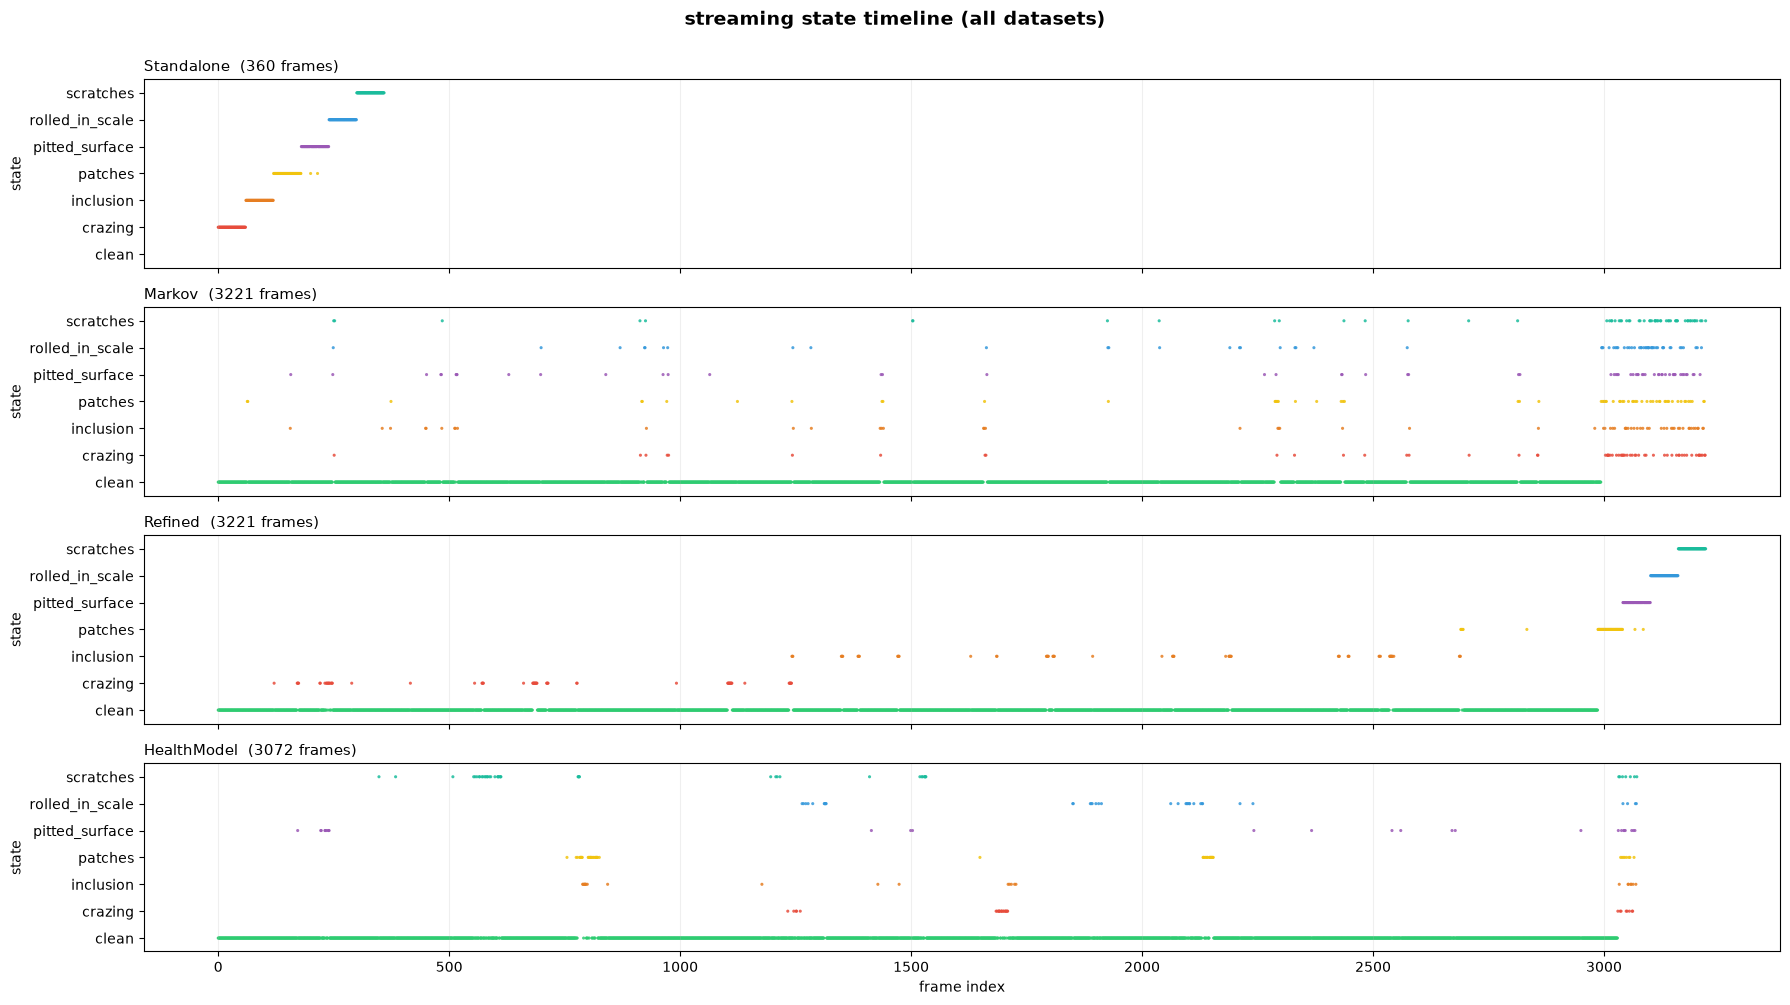

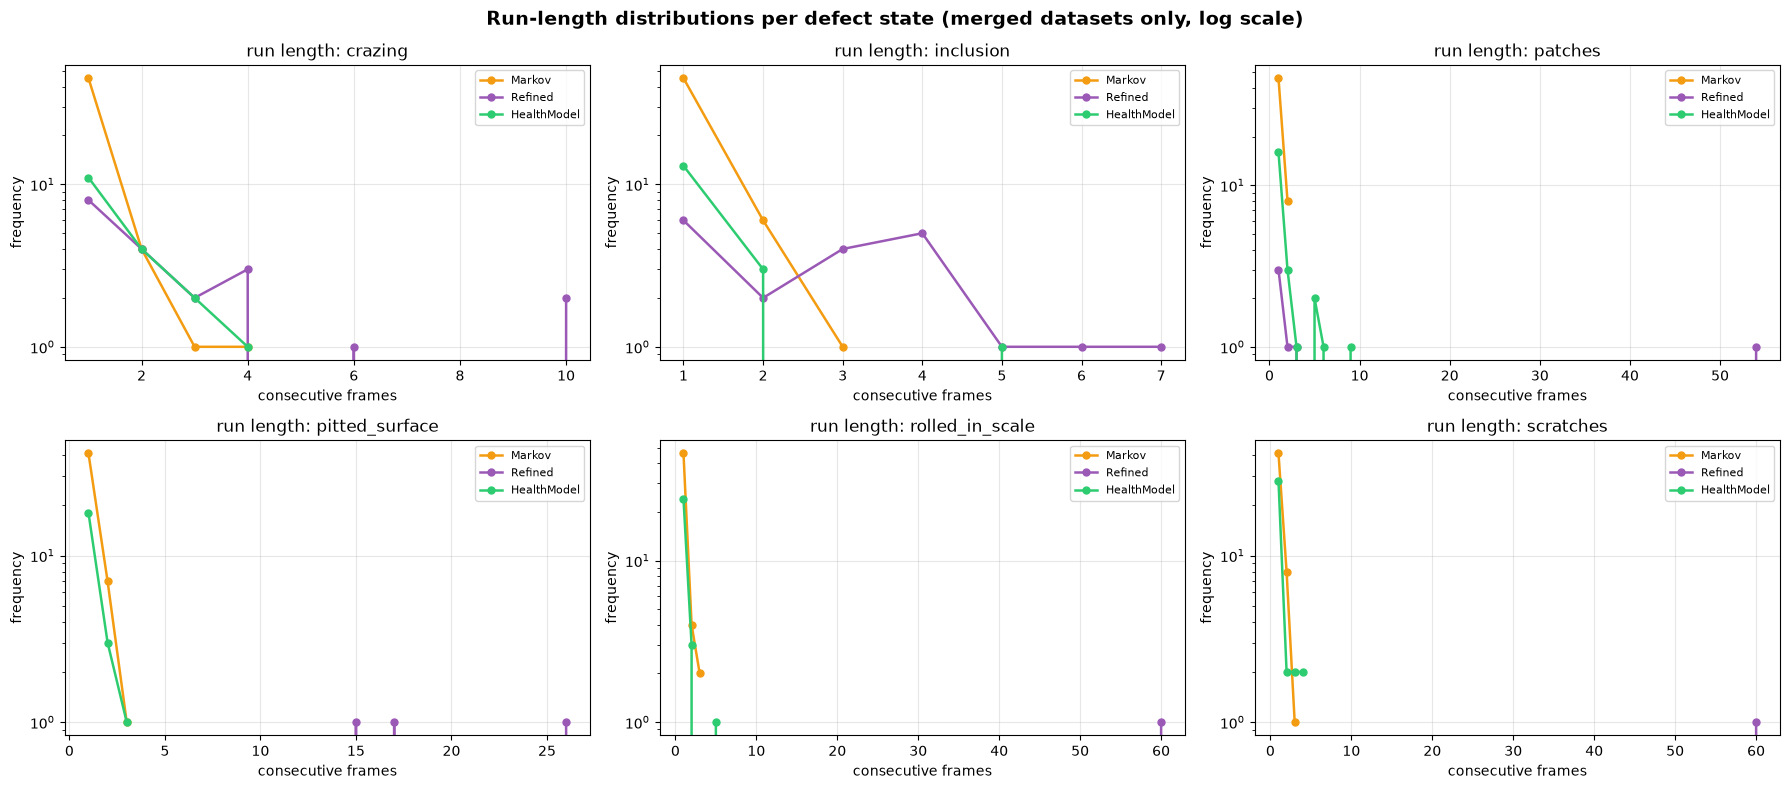

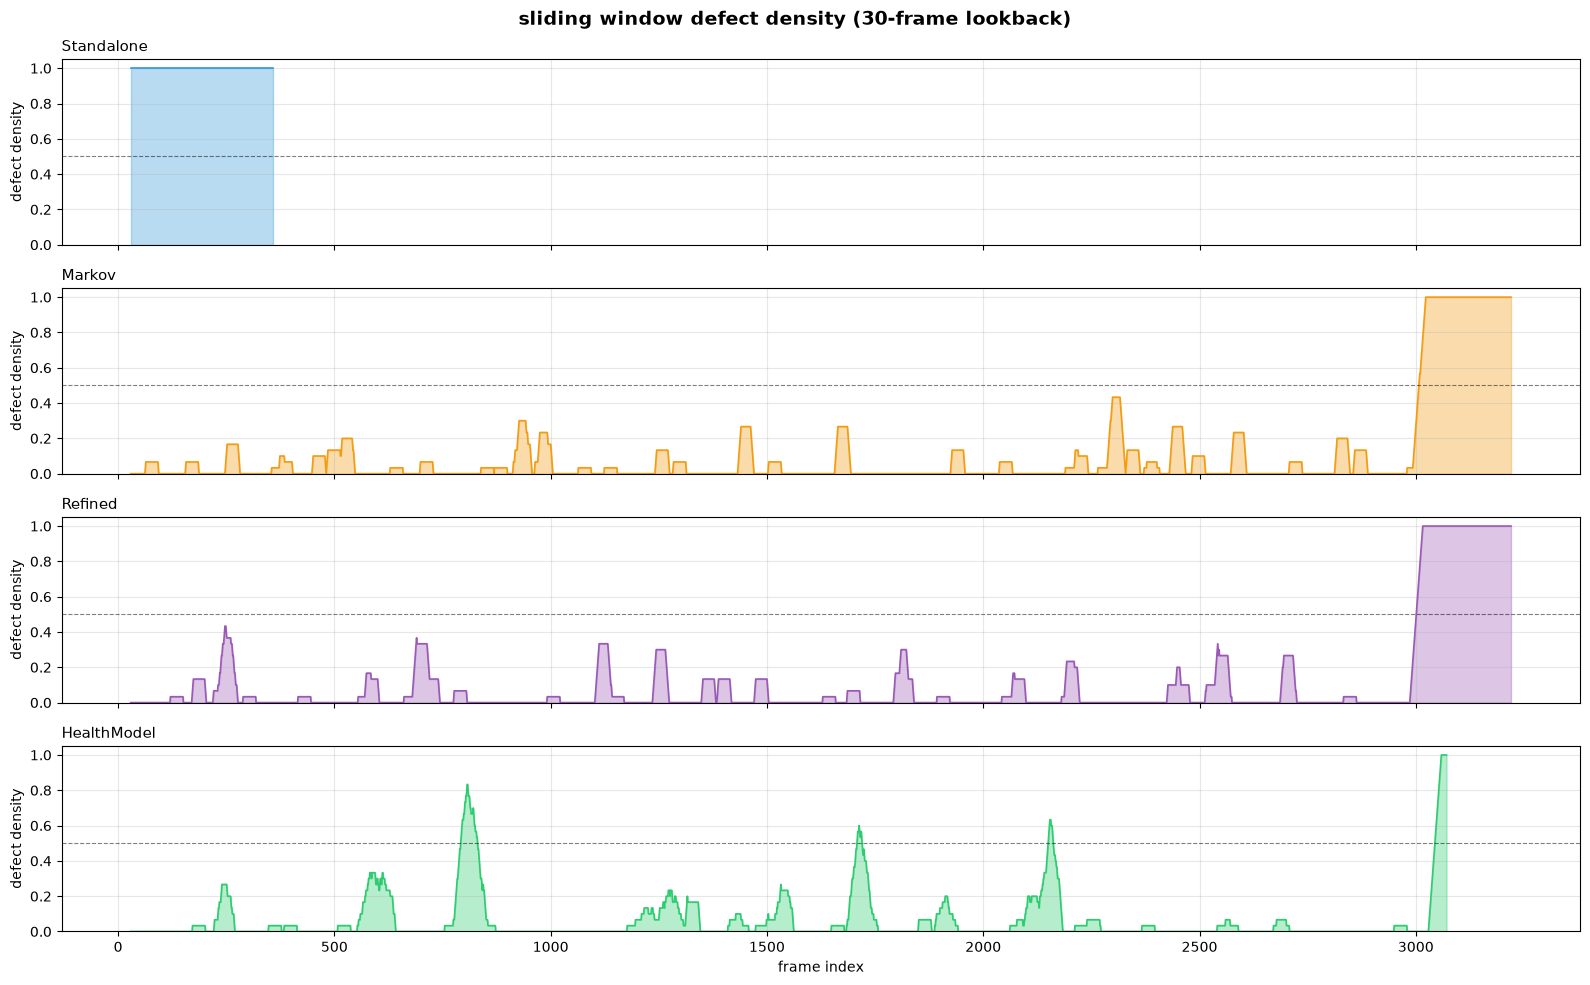

[block 3 complete] process dashboards generated.


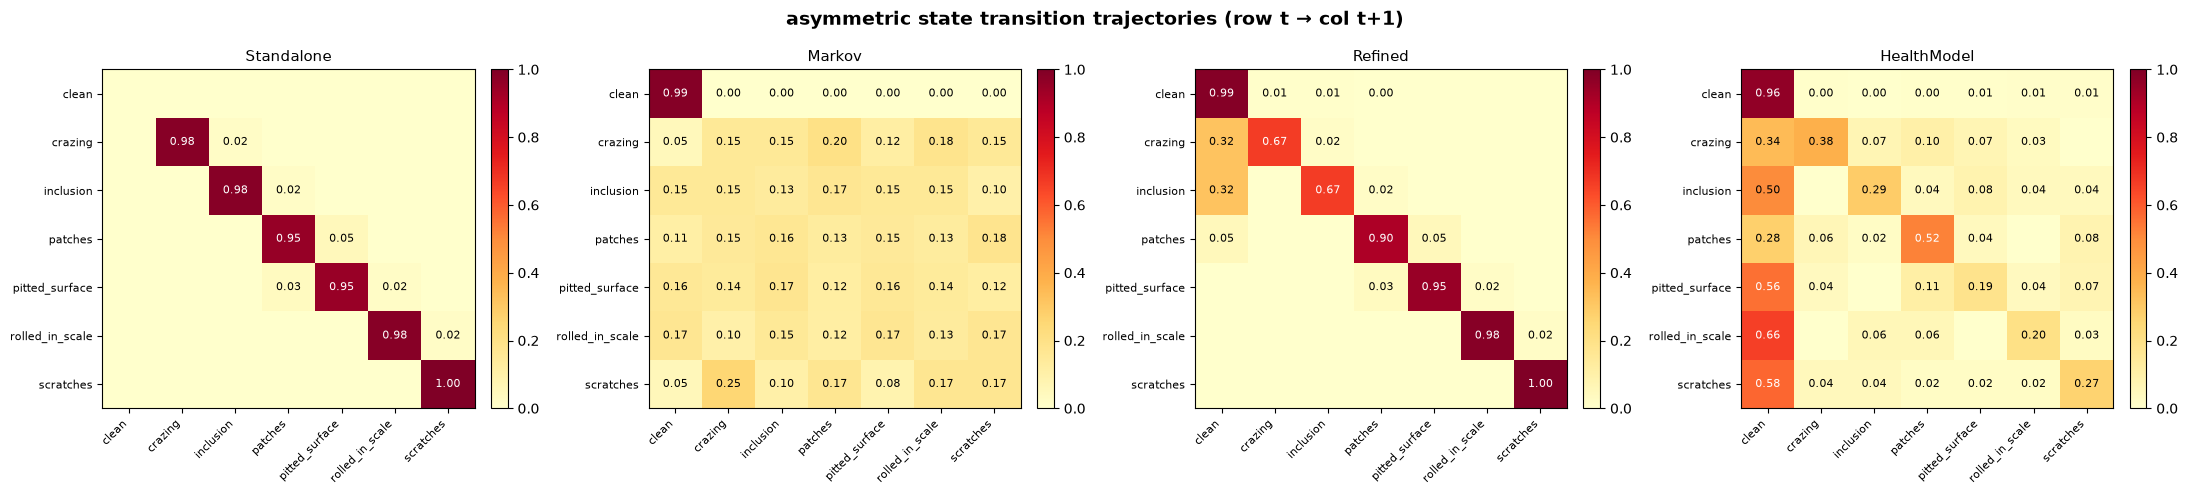

[block 4 complete] heatmaps generated.


In [57]:
# config
STANDALONE_IMG_DIR = "NEU_DET_YOLO_Ready/images/val"
STANDALONE_LBL_DIR = "NEU_DET_YOLO_Ready/labels/val"
results_dir = Path("./methodsComparisonResults")
os.makedirs(results_dir, exist_ok=True)

# merged datasets
MERGED_DATASETS = {
    "Markov": "MarkovChain",
    "Refined": "RefinedMarkovChain",
    "HealthModel": "healthModel",
}

# class map
CLASS_MAP = {
    0: "crazing",
    1: "inclusion",
    2: "patches",
    3: "pitted_surface",
    4: "rolled_in_scale",
    5: "scratches",
}

ALL_STATES = [
    "clean",
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled_in_scale",
    "scratches",
]

STATE_COLORS = {
    "clean": "#2ecc71",
    "crazing": "#e74c3c",
    "inclusion": "#e67e22",
    "patches": "#f1c40f",
    "pitted_surface": "#9b59b6",
    "rolled_in_scale": "#3498db",
    "scratches": "#1abc9c",
}

DATASET_COLORS = {
    "Standalone": "#3498db",
    "Markov": "#f39c12",
    "Refined": "#9b59b6",
    "HealthModel": "#2ecc71",
}

# parsing functions
def get_dominant_class(label_path):
    """dominant class logic, clean for empty"""
    if not os.path.exists(label_path) or os.path.getsize(label_path) == 0:
        return "clean"

    class_ids = []
    with open(label_path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                parts = line.split()
                if len(parts) >= 1:
                    try:
                        class_ids.append(int(parts[0]))
                    except ValueError:
                        continue

    if not class_ids:
        return "clean"

    dominant_id = Counter(class_ids).most_common(1)[0][0]
    return CLASS_MAP.get(dominant_id, "unknown")


def parse_standalone(img_dir, lbl_dir):
    """parse standalone validation set"""
    records = []
    img_files = sorted(
        f for f in os.listdir(img_dir)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    )

    for img_file in img_files:
        base = os.path.splitext(img_file)[0]
        lbl_path = os.path.join(lbl_dir, base + ".txt")
        state = get_dominant_class(lbl_path)

        records.append({
            "filename": img_file,
            "state": state,
            "source": "standalone",
        })
    return records


def parse_merged(img_dir, lbl_dir):
    """parse merged timeline with temporal ordering"""
    records = []
    img_files = [
        f for f in os.listdir(img_dir)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    def frame_key(fname):
        m = re.search(r"frame(\d+)", fname)
        return int(m.group(1)) if m else 0

    img_files.sort(key=frame_key)

    for img_file in img_files:
        m = re.search(r"frame\d+_([a-z_]+)\.", img_file)
        filename_state = m.group(1) if m else "unknown"

        base = os.path.splitext(img_file)[0]
        lbl_path = os.path.join(lbl_dir, base + ".txt")

        is_multi = False
        if os.path.exists(lbl_path) and os.path.getsize(lbl_path) > 0:
            with open(lbl_path, "r") as f:
                lines = [l.strip() for l in f if l.strip()]
            ids = [int(l.split()[0]) for l in lines if l.split()]

            if len(set(ids)) > 1:
                is_multi = True
                effective_state = get_dominant_class(lbl_path)
            else:
                effective_state = filename_state
        else:
            effective_state = "clean"

        records.append({
            "filename": img_file,
            "state": effective_state,
            "filename_state": filename_state,
            "is_multi_label": is_multi,
            "source": "merged",
        })

    return records


# execute parsing
print("parsing standalone...")
standalone_records = parse_standalone(STANDALONE_IMG_DIR, STANDALONE_LBL_DIR)
standalone_seq = [r["state"] for r in standalone_records]
print(f"  -> {len(standalone_records)} frames")

datasets = {
    "Standalone": standalone_seq,
}

for name, path in MERGED_DATASETS.items():
    img_dir = os.path.join(path, "images", "val")
    lbl_dir = os.path.join(path, "labels", "val")
    
    print(f"\nparsing {name}...")
    if not os.path.exists(img_dir):
        print(f"  warning: path not found {img_dir}")
        continue
        
    records = parse_merged(img_dir, lbl_dir)
    datasets[name] = [r["state"] for r in records]
    multi_count = sum(1 for r in records if r["is_multi_label"])
    print(f"  -> {len(records)} frames")
    print(f"  -> multi-label frames resolved: {multi_count}")

print(f"\n[block 1 complete] {len(datasets)} datasets parsed.")
print(f"  keys: {list(datasets.keys())}")

# metric functions
def compute_run_lengths(sequence):
    if not sequence:
        return {}
    runs = defaultdict(list)
    current_state = sequence[0]
    current_len = 1
    for state in sequence[1:]:
        if state == current_state:
            current_len += 1
        else:
            runs[current_state].append(current_len)
            current_state = state
            current_len = 1
    runs[current_state].append(current_len)
    return dict(runs)


def compute_switching_frequency(sequence):
    if len(sequence) < 2:
        return 0.0
    switches = sum(1 for i in range(1, len(sequence)) if sequence[i] != sequence[i-1])
    return 100.0 * switches / (len(sequence) - 1)


def compute_transition_matrix(sequence, states):
    counts = pd.DataFrame(0, index=states, columns=states)
    for i in range(len(sequence) - 1):
        s1, s2 = sequence[i], sequence[i+1]
        if s1 in counts.index and s2 in counts.columns:
            counts.loc[s1, s2] += 1
    return counts


# compute metrics for all datasets
results = {}

for name, seq in datasets.items():
    print(f"\n{'=' * 75}")
    print(f"  dataset: {name}")
    print(f"{'=' * 75}")

    total = len(seq)
    defect_rate = 100.0 * sum(1 for s in seq if s != "clean") / total if total else 0.0
    switch_freq = compute_switching_frequency(seq)
    runs = compute_run_lengths(seq)
    trans = compute_transition_matrix(seq, ALL_STATES)

    results[name] = {
        "total": total,
        "defect_rate": defect_rate,
        "switch_freq": switch_freq,
        "runs": runs,
        "transitions": trans,
    }

    print(f"  total frames              : {total}")
    print(f"  defect rate               : {defect_rate:.2f} %")
    print(f"  switching frequency       : {switch_freq:.2f} %")

    print(f"\n  (d) average state persistence / run-length:")
    print(f"  {'state':<20} {'mean':>8} {'std':>8} {'max':>6} {'runs':>6}")
    print(f"  {'-' * 20} {'-' * 8} {'-' * 8} {'-' * 6} {'-' * 6}")

    for state in ALL_STATES:
        if state in runs and runs[state]:
            mean_rl = np.mean(runs[state])
            std_rl = np.std(runs[state])
            max_rl = max(runs[state])
            n_runs = len(runs[state])
            print(f"  {state:<20} {mean_rl:>8.2f} {std_rl:>8.2f} {max_rl:>6} {n_runs:>6}")
        else:
            print(f"  {state:<20} {'n/a':>8} {'n/a':>8} {'n/a':>6} {'0':>6}")

    print(f"\n  (e) state transition matrix (row t -> col t+1) [raw counts]:")
    print(trans.to_string())


# side-by-side comparison
print(f"\n{'=' * 75}")
print("  comparative summary (all datasets)")
print(f"{'=' * 75}")

names = list(results.keys())
header = f"  {'metric':<40}"
for n in names:
    header += f" {n:>12}"
print(header)
print(f"  {'-' * 40}" + "".join(f" {'-' * 12}" for _ in names))

metrics = [
    ("total frames", lambda r: f"{r['total']}"),
    ("defect rate (%)", lambda r: f"{r['defect_rate']:.2f}"),
    ("switching freq (%)", lambda r: f"{r['switch_freq']:.2f}"),
    ("avg clean run", lambda r: f"{np.mean(r['runs'].get('clean', [0])):.2f}"),
    ("avg defect run", lambda r: f"{np.mean([v for s, runs in r['runs'].items() if s != 'clean' for v in runs]) if any(r['runs'].get(s, []) for s in ALL_STATES if s != 'clean') else 0:.2f}"),
    ("max defect run", lambda r: f"{max([max(r['runs'].get(s, [0])) for s in ALL_STATES if s != 'clean']) if any(r['runs'].get(s, []) for s in ALL_STATES if s != 'clean') else 0}"),
]

for label, fn in metrics:
    row = f"  {label:<40}"
    for n in names:
        row += f" {fn(results[n]):>12}"
    print(row)

print("\n[block 2 complete] metrics computed.")

# visualizations

# figure 1: timeline
def state_to_numeric(state):
    return ALL_STATES.index(state) if state in ALL_STATES else -1

n_ds = len(datasets)
fig, axes = plt.subplots(n_ds, 1, figsize=(18, 2.5 * n_ds), sharex=True)

if n_ds == 1:
    axes = [axes]

for ax, (name, seq) in zip(axes, datasets.items()):
    x = list(range(len(seq)))
    y = [state_to_numeric(s) for s in seq]
    colors = [STATE_COLORS.get(s, "gray") for s in seq]

    ax.scatter(x, y, c=colors, s=5, alpha=0.85, edgecolors="none")
    ax.set_yticks(range(len(ALL_STATES)))
    ax.set_yticklabels(ALL_STATES)
    ax.set_ylim(-0.5, len(ALL_STATES) - 0.5)
    ax.set_title(f"{name}  ({len(seq)} frames)", loc="left", fontsize=11)
    ax.set_ylabel("state")
    ax.grid(True, alpha=0.2, axis="x")

axes[-1].set_xlabel("frame index")
plt.suptitle("streaming state timeline (all datasets)", fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(results_dir,"timeline.png"), dpi=150, bbox_inches="tight")
plt.show()

# figure 2: run-length distribution
DEFECT_STATES = [s for s in ALL_STATES if s != "clean"]   # 6 states

# Filter out Standalone – keep only the merged datasets
PLOT_DATASETS = {k: v for k, v in datasets.items() if k != "Standalone"}

n_cols = 3
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 8))
axes = axes.flatten()

for idx, state in enumerate(DEFECT_STATES):
    ax = axes[idx]

    for name, seq in PLOT_DATASETS.items():
        runs = results[name]["runs"].get(state, [])
        if runs:
            max_run = max(runs)
            bins = np.arange(0.5, max_run + 1.5, 1)
            counts, bin_edges = np.histogram(runs, bins=bins)
            centers = (bin_edges[:-1] + bin_edges[1:]) / 2

            ax.plot(centers, counts,
                    marker='o', linestyle='-', linewidth=1.8,
                    markersize=5,
                    label=name,
                    color=DATASET_COLORS.get(name, 'gray'))

    ax.set_title(f"run length: {state}", fontsize=12)
    ax.set_xlabel("consecutive frames")
    ax.set_ylabel("frequency")
    ax.set_yscale('log')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

for idx in range(len(DEFECT_STATES), len(axes)):
    axes[idx].axis('off')

plt.suptitle("Run-length distributions per defect state (merged datasets only, log scale)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(results_dir,"runLength_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
# figure 3: sliding window defect density
WINDOW_SIZE = 30

fig, axes = plt.subplots(n_ds, 1, figsize=(16, 2.5 * n_ds), sharex=True)

if n_ds == 1:
    axes = [axes]

for ax, (name, seq) in zip(axes, datasets.items()):
    defect_signal = np.array([0 if s == "clean" else 1 for s in seq])

    if len(defect_signal) >= WINDOW_SIZE:
        kernel = np.ones(WINDOW_SIZE) / WINDOW_SIZE
        density = np.convolve(defect_signal, kernel, mode="valid")
        x = np.arange(WINDOW_SIZE - 1, len(defect_signal))
    else:
        density = []
        x = []

    ax.fill_between(x, density, alpha=0.35, color=DATASET_COLORS.get(name, "#e74c3c"))
    ax.plot(x, density, color=DATASET_COLORS.get(name, "#c0392b"), linewidth=1.2)
    ax.axhline(y=0.5, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{name}", loc="left", fontsize=11)
    ax.set_ylabel("defect density")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("frame index")
plt.suptitle(f"sliding window defect density ({WINDOW_SIZE}-frame lookback)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(results_dir,"defectDensity.png"), dpi=150, bbox_inches="tight")
plt.show()

print("[block 3 complete] process dashboards generated.")

# transition dynamics
n_ds = len(datasets)
cols = min(4, n_ds)
rows = (n_ds + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5.5 * cols, 5 * rows))

if n_ds == 1:
    axes = np.array([axes])
axes = axes.flatten()

for ax, (name, seq) in zip(axes, datasets.items()):
    trans = results[name]["transitions"]
    trans_prob = trans.div(trans.sum(axis=1), axis=0).fillna(0)

    im = ax.imshow(trans_prob.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(ALL_STATES)))
    ax.set_yticks(range(len(ALL_STATES)))
    ax.set_xticklabels(ALL_STATES, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(ALL_STATES, fontsize=8)
    ax.set_title(f"{name}", fontsize=11)

    for i in range(len(ALL_STATES)):
        for j in range(len(ALL_STATES)):
            val = trans_prob.iloc[i, j]
            if val > 0:
                ax.text(
                    j, i, f"{val:.2f}",
                    ha="center", va="center",
                    color="white" if val > 0.5 else "black",
                    fontsize=8,
                )

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for idx in range(n_ds, len(axes)):
    axes[idx].axis("off")

plt.suptitle("asymmetric state transition trajectories (row t → col t+1)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(results_dir,"transitionHeatMap.png"), dpi=150, bbox_inches="tight")
plt.show()

print("[block 4 complete] heatmaps generated.")

## 6. Samples for Simulation 
__objective: creating short sample, each sample representing a real challenge that might occur in actual factury setting__
#### sample 1: long tail

In [ ]:
# config
BASE_DIR = Path("healthModel")
SOURCE_IMAGES = BASE_DIR / "images" / "val"
SOURCE_LABELS = BASE_DIR / "labels" / "val"
OUTPUT_DIR = Path("sample_1_longtail")
OUTPUT_IMAGES = OUTPUT_DIR / "images" / "val"
OUTPUT_LABELS = OUTPUT_DIR / "labels" / "val"

SAMPLE_SIZE = 100
RANDOM_SEED = 42

CLASS_NAMES = [
    "crazing", "inclusion", "patches", "pitted_surface",
    "rolled-in_scale", "scratches"
]

random.seed(RANDOM_SEED)

# read labels
def read_yolo_labels(label_path):
    if not label_path.exists():
        return []
    with open(label_path, "r") as f:
        lines = [line.strip() for line in f if line.strip()]
    class_ids = set()
    for line in lines:
        parts = line.split()
        if len(parts) >= 5:
            class_ids.add(int(parts[0]))
    return sorted(class_ids)

def get_defect_classes_from_ids(class_ids):
    return [CLASS_NAMES[cid] for cid in class_ids if 0 <= cid < len(CLASS_NAMES)]

def main():
    all_images = sorted([f for f in SOURCE_IMAGES.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]])
    print(f"Found {len(all_images)} images in source.")

    # categorize
    clean_images = []
    defect_images = defaultdict(list)
    image_classes = {}

    for img_path in all_images:
        label_path = SOURCE_LABELS / (img_path.stem + ".txt")
        cids = read_yolo_labels(label_path)
        classes = get_defect_classes_from_ids(cids)
        image_classes[img_path] = classes
        
        if not classes:
            clean_images.append(img_path)
        else:
            for c in classes:
                defect_images[c].append(img_path)

    # quotas
    class_quotas = {
        "inclusion": 1,
        "rolled-in_scale": 1,
        "crazing": 3,
        "pitted_surface": 3,
        "patches": 10,
        "scratches": 12
    }
    target_clean = 80

    selected = set()

    # satisfy defect quotas
    for class_name, quota in class_quotas.items():
        already_have = sum(1 for img in selected if class_name in image_classes[img])
        still_needed = max(0, quota - already_have)
        available = [img for img in defect_images[class_name] if img not in selected]
        pick = min(still_needed, len(available))
        if pick > 0:
            chosen = random.sample(available, pick)
            selected.update(chosen)

    # fill clean
    clean_pool = [c for c in clean_images if c not in selected]
    clean_pick = min(target_clean, len(clean_pool))
    selected.update(random.sample(clean_pool, clean_pick))

    # adjust to exact size
    while len(selected) < SAMPLE_SIZE:
        remaining_clean = [c for c in clean_images if c not in selected]
        if remaining_clean:
            selected.add(random.choice(remaining_clean))
        else:
            remaining_defect = [img for img in all_images if img not in selected and image_classes[img]]
            if remaining_defect:
                selected.add(random.choice(remaining_defect))
            else:
                break

    while len(selected) > SAMPLE_SIZE:
        clean_selected = [img for img in selected if not image_classes[img]]
        if clean_selected:
            selected.remove(random.choice(clean_selected))
        else:
            scratch_only = [img for img in selected 
                          if "scratches" in image_classes[img] and len(image_classes[img]) == 1]
            if scratch_only:
                selected.remove(random.choice(scratch_only))
            else:
                patch_only = [img for img in selected 
                            if "patches" in image_classes[img] and len(image_classes[img]) == 1]
                if patch_only:
                    selected.remove(random.choice(patch_only))
                else:
                    scratch_any = [img for img in selected if "scratches" in image_classes[img]]
                    if scratch_any:
                        selected.remove(random.choice(scratch_any))
                    else:
                        break

    final_selection = sorted(list(selected), key=lambda p: p.stem)
    
    # report distribution
    dist_counter = Counter()
    for img_path in final_selection:
        classes = image_classes[img_path]
        if not classes:
            dist_counter["clean"] += 1
        else:
            for c in classes:
                dist_counter[c] += 1

    print(f"\nSelected {len(final_selection)} images for Sample 1.")
    print(f"Defect rate: {(len(final_selection) - dist_counter['clean']) / len(final_selection) * 100:.1f}%")
    print("Achieved distribution (images containing each class):")
    print("-" * 45)
    for k, v in sorted(dist_counter.items(), key=lambda x: x[1], reverse=True):
        print(f"  {k:20s}: {v:3d}")

    # copy files
    OUTPUT_IMAGES.mkdir(parents=True, exist_ok=True)
    OUTPUT_LABELS.mkdir(parents=True, exist_ok=True)
    
    for img_path in final_selection:
        label_path = SOURCE_LABELS / (img_path.stem + ".txt")
        shutil.copy2(img_path, OUTPUT_IMAGES / img_path.name)
        if label_path.exists():
            shutil.copy2(label_path, OUTPUT_LABELS / label_path.name)
        else:
            (OUTPUT_LABELS / (img_path.stem + ".txt")).touch()
    
    print(f"\nSample 1 created at: {OUTPUT_DIR.resolve()}")

if __name__ == "__main__":
    main()

Found 3072 images in source.

Selected 100 images for Sample 1.
Defect rate: 29.0%
Achieved distribution (images containing each class):
---------------------------------------------
  clean               :  71
  scratches           :  12
  patches             :  10
  pitted_surface      :   5
  crazing             :   3
  inclusion           :   1
  rolled-in_scale     :   1

Sample 1 created at: C:\Users\acer\Desktop\DataAugmentation\sample_1_longtail


Visualization saved to: C:\Users\acer\Desktop\DataAugmentation\sample1_visualization.png


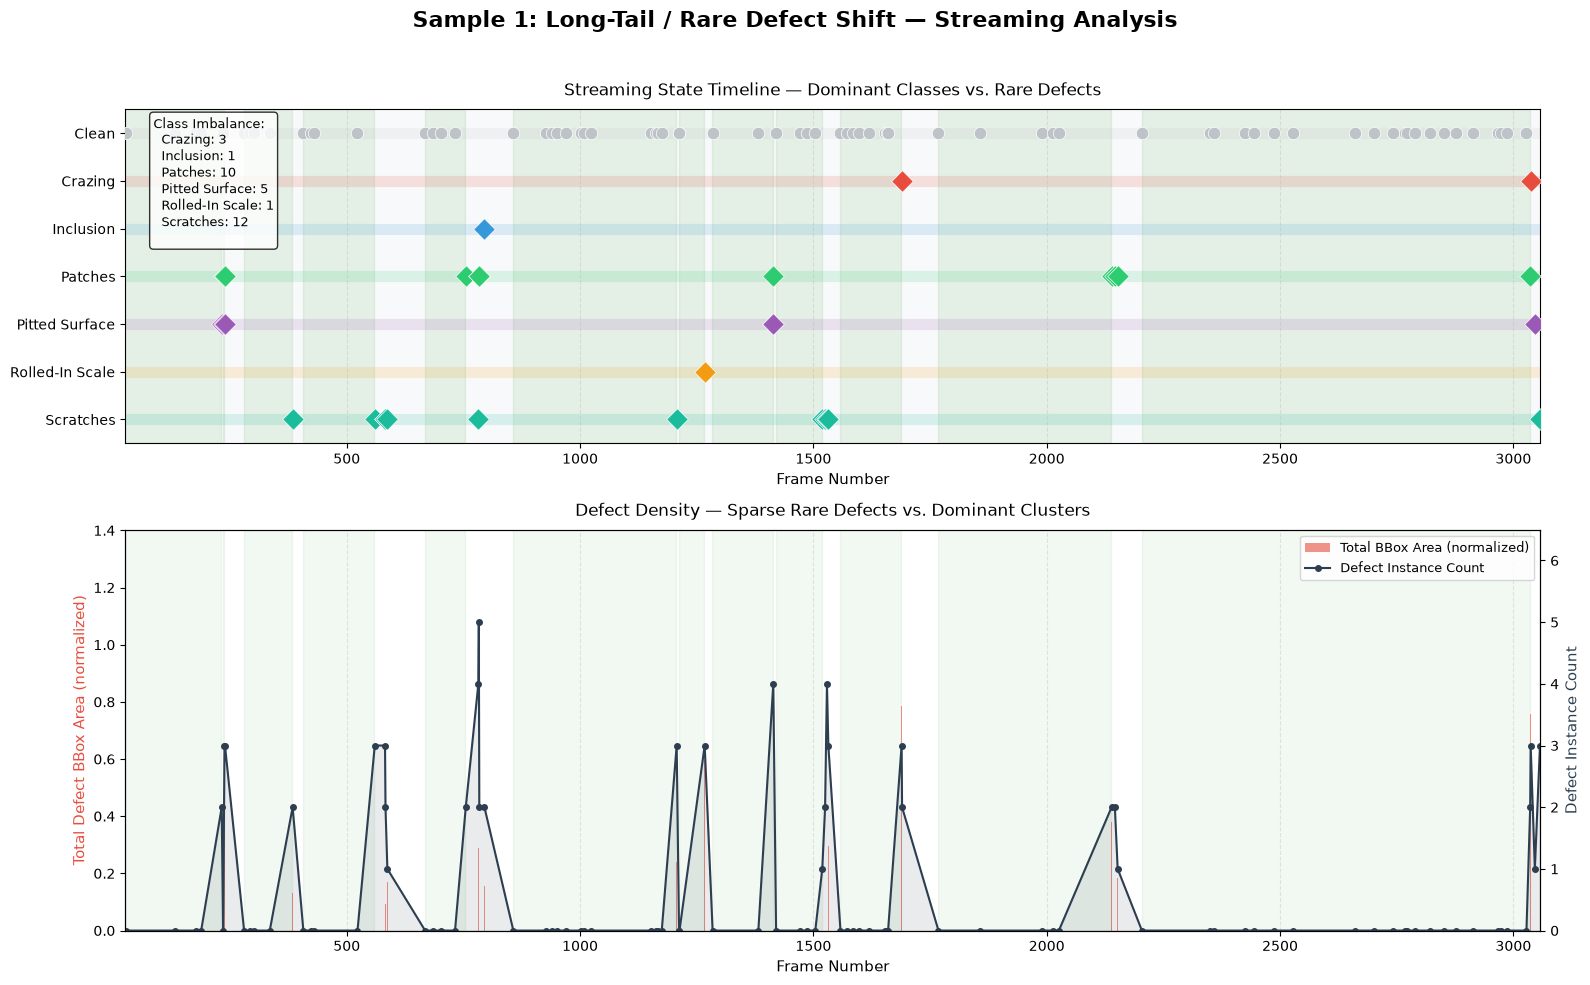

In [75]:
SAMPLE_DIR = Path("sample_1_longtail")
SAMPLE_IMAGES = SAMPLE_DIR / "images" / "val"
SAMPLE_LABELS = SAMPLE_DIR / "labels" / "val"
OUTPUT_PLOT = Path("sample1_visualization.png")

CLASS_NAMES = [
    "crazing", "inclusion", "patches", "pitted_surface",
    "rolled-in_scale", "scratches"
]
CLASS_COLORS = {
    "crazing": "#e74c3c",
    "inclusion": "#3498db",
    "patches": "#2ecc71",
    "pitted_surface": "#9b59b6",
    "rolled-in_scale": "#f39c12",
    "scratches": "#1abc9c",
    "clean": "#bdc3c7"
}

# read labels
def read_yolo_labels(label_path):
    if not label_path.exists():
        return []
    with open(label_path, "r") as f:
        lines = [line.strip() for line in f if line.strip()]
    entries = []
    for line in lines:
        parts = line.split()
        if len(parts) >= 5:
            cid = int(parts[0])
            bbox = [float(x) for x in parts[1:5]]
            entries.append((cid, bbox))
    return entries

def main():
    all_images = sorted([f for f in SAMPLE_IMAGES.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]])
    
    frames = []
    for img_path in all_images:
        stem = img_path.stem
        frame_num = int(stem.split("_")[0].replace("frame", ""))
        label_path = SAMPLE_LABELS / (stem + ".txt")
        entries = read_yolo_labels(label_path)
        
        defects = []
        total_area = 0.0
        for cid, bbox in entries:
            name = CLASS_NAMES[cid]
            area = bbox[2] * bbox[3]
            total_area += area
            defects.append(name)
        
        frames.append({
            "num": frame_num,
            "name": img_path.name,
            "defects": defects,
            "total_area": total_area,
            "is_clean": len(defects) == 0
        })
    
    frames.sort(key=lambda x: x["num"])
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [1, 1.2]})
    fig.suptitle("Sample 1: Long-Tail / Rare Defect Shift — Streaming Analysis", 
                 fontsize=16, fontweight='bold')

    # timeline plot
    ax1 = axes[0]
    ax1.set_facecolor("#f8f9fa")
    
    y_positions = {"clean": 0}
    for i, name in enumerate(CLASS_NAMES):
        y_positions[name] = i + 1
    
    class_occurrences = defaultdict(int)
    
    for frame in frames:
        x = frame["num"]
        if frame["is_clean"]:
            ax1.scatter(x, y_positions["clean"], c=CLASS_COLORS["clean"], 
                       s=80, zorder=3, edgecolors='white', linewidth=0.5)
        else:
            for d in set(frame["defects"]):
                ax1.scatter(x, y_positions[d], c=CLASS_COLORS[d], 
                           s=120, zorder=3, edgecolors='white', linewidth=0.5, marker='D')
                class_occurrences[d] += 1
    
    for name, y in y_positions.items():
        ax1.axhline(y=y, color=CLASS_COLORS[name], alpha=0.15, linewidth=8, zorder=1)
    
    ax1.set_yticks(list(y_positions.values()))
    ax1.set_yticklabels([k.replace("_", " ").title() for k in y_positions.keys()])
    ax1.set_xlabel("Frame Number", fontsize=11)
    ax1.set_title("Streaming State Timeline — Dominant Classes vs. Rare Defects", fontsize=12, pad=10)
    ax1.set_xlim(frames[0]["num"] - 1, frames[-1]["num"] + 1)
    ax1.set_ylim(-0.5, len(y_positions) - 0.5)
    ax1.grid(axis='x', alpha=0.3, linestyle='--')
    ax1.invert_yaxis()
    
    annot_text = "Class Imbalance:\n"
    for name in CLASS_NAMES:
        count = class_occurrences.get(name, 0)
        annot_text += f"  {name.replace('_', ' ').title()}: {count}\n"
    ax1.text(0.02, 0.98, annot_text, transform=ax1.transAxes, fontsize=9,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # defect density plot
    ax2 = axes[1]
    
    x_vals = [f["num"] for f in frames]
    y_density = [f["total_area"] for f in frames]
    y_count = [len(f["defects"]) for f in frames]
    
    bars = ax2.bar(x_vals, y_density, color="#e74c3c", alpha=0.6, width=0.8, 
                   label="Total BBox Area (normalized)")
    ax2_twin = ax2.twinx()
    ax2_twin.plot(x_vals, y_count, color="#2c3e50", marker='o', markersize=4, 
                  linewidth=1.5, label="Defect Instance Count")
    ax2_twin.fill_between(x_vals, y_count, alpha=0.1, color="#2c3e50")
    
    ax2.set_xlabel("Frame Number", fontsize=11)
    ax2.set_ylabel("Total Defect BBox Area (normalized)", fontsize=11, color="#e74c3c")
    ax2_twin.set_ylabel("Defect Instance Count", fontsize=11, color="#2c3e50")
    ax2.set_title("Defect Density — Sparse Rare Defects vs. Dominant Clusters", fontsize=12, pad=10)
    ax2.set_xlim(frames[0]["num"] - 1, frames[-1]["num"] + 1)
    ax2.set_ylim(0, max(y_density) * 1.3 if max(y_density) > 0 else 1)
    ax2_twin.set_ylim(0, max(y_count) * 1.3 if max(y_count) > 0 else 1)
    ax2.grid(axis='x', alpha=0.3, linestyle='--')
    
    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2_twin.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)
    
    # highlight clean frames
    clean_ranges = []
    in_clean = False
    start = None
    for f in frames:
        if f["is_clean"] and not in_clean:
            start = f["num"]
            in_clean = True
        elif not f["is_clean"] and in_clean:
            clean_ranges.append((start, f["num"] - 1))
            in_clean = False
    if in_clean:
        clean_ranges.append((start, frames[-1]["num"]))
    
    for s, e in clean_ranges:
        ax1.axvspan(s - 0.4, e + 0.4, alpha=0.08, color='green', zorder=0)
        ax2.axvspan(s - 0.4, e + 0.4, alpha=0.05, color='green', zorder=0)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(OUTPUT_PLOT, dpi=200, bbox_inches='tight', facecolor='white')
    print(f"Visualization saved to: {OUTPUT_PLOT.resolve()}")
    plt.show()

if __name__ == "__main__":
    main()

#### sample 2: high defect density (70%)

In [78]:
OUTPUT_DIR = Path("sample_2_high_density")
OUTPUT_IMAGES = OUTPUT_DIR / "images" / "val"
OUTPUT_LABELS = OUTPUT_DIR / "labels" / "val"

SAMPLE_SIZE = 100
DEFECT_RATIO = 0.70
RANDOM_SEED = 42

CLASS_NAMES = [
    "crazing", "inclusion", "patches", "pitted_surface",
    "rolled-in_scale", "scratches"
]

random.seed(RANDOM_SEED)

# read labels
def read_yolo_labels(label_path):
    if not label_path.exists():
        return []
    with open(label_path, "r") as f:
        lines = [line.strip() for line in f if line.strip()]
    entries = []
    for line in lines:
        parts = line.split()
        if len(parts) >= 5:
            cid = int(parts[0])
            bbox = [float(x) for x in parts[1:5]]
            entries.append((cid, bbox))
    return entries

def main():
    all_images = sorted([
        f for f in SOURCE_IMAGES.iterdir()
        if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ])
    print(f"Found {len(all_images)} images in source.")

    # score images
    scored_defect = []
    clean_pool = []

    for img_path in all_images:
        stem = img_path.stem
        label_path = SOURCE_LABELS / (stem + ".txt")
        entries = read_yolo_labels(label_path)

        total_area = 0.0
        defect_classes = set()
        instance_count = 0

        for cid, bbox in entries:
            area = bbox[2] * bbox[3]
            total_area += area
            defect_classes.add(CLASS_NAMES[cid])
            instance_count += 1

        if len(entries) == 0:
            clean_pool.append({
                "path": img_path,
                "stem": stem,
                "total_area": 0.0,
                "classes": set(),
                "instance_count": 0,
                "is_clean": True
            })
        else:
            scored_defect.append({
                "path": img_path,
                "stem": stem,
                "total_area": total_area,
                "classes": defect_classes,
                "instance_count": instance_count,
                "is_clean": False
            })

    # sort by density
    scored_defect.sort(key=lambda x: x["total_area"], reverse=True)

    target_defect = int(SAMPLE_SIZE * DEFECT_RATIO)
    target_clean = SAMPLE_SIZE - target_defect

    selected_defect = scored_defect[:target_defect]
    random.shuffle(clean_pool)
    selected_clean = clean_pool[:target_clean]

    combined = selected_defect + selected_clean
    final_selection = sorted(combined, key=lambda x: int(x["stem"].split("_")[0].replace("frame", "")))

    # report
    dist_counter = Counter()
    clean_count = 0
    multi_defect_count = 0
    max_area = 0.0
    max_instances = 0
    total_area_sum = 0.0

    for item in final_selection:
        total_area_sum += item["total_area"]
        max_area = max(max_area, item["total_area"])
        max_instances = max(max_instances, item["instance_count"])

        if item["is_clean"]:
            clean_count += 1
            dist_counter["clean"] += 1
        else:
            if len(item["classes"]) > 1:
                multi_defect_count += 1
            for c in item["classes"]:
                dist_counter[c] += 1

    print(f"\n{'=' * 55}")
    print(f"SAMPLE 2: HIGH-DENSITY DEFECT ZONE (70/30)")
    print(f"{'=' * 55}")
    print(f"Total images: {len(final_selection)}")
    print(f"High-density defect frames: {len(final_selection) - clean_count}")
    print(f"Clean frames: {clean_count}")
    print(f"Multi-defect images: {multi_defect_count}")
    print(f"Maximum defect area in a single frame: {max_area:.4f}")
    print(f"Maximum instances in a single frame: {max_instances}")
    print(f"Average defect area per frame: {total_area_sum / len(final_selection):.4f}")
    print(f"\nClass distribution (unique images per class):")
    for name in CLASS_NAMES:
        count = dist_counter.get(name, 0)
        print(f"  {name:20s}: {count}")
    print(f"{'=' * 55}")

    # copy files
    OUTPUT_IMAGES.mkdir(parents=True, exist_ok=True)
    OUTPUT_LABELS.mkdir(parents=True, exist_ok=True)

    for item in final_selection:
        img_path = item["path"]
        label_path = SOURCE_LABELS / (item["stem"] + ".txt")
        shutil.copy2(img_path, OUTPUT_IMAGES / img_path.name)
        if label_path.exists():
            shutil.copy2(label_path, OUTPUT_LABELS / label_path.name)
        else:
            (OUTPUT_LABELS / (item["stem"] + ".txt")).touch()

    print(f"\nSample 2 created at: {OUTPUT_DIR.resolve()}")

if __name__ == "__main__":
    main()

Found 3072 images in source.

SAMPLE 2: HIGH-DENSITY DEFECT ZONE (70/30)
Total images: 100
High-density defect frames: 70
Clean frames: 30
Multi-defect images: 7
Maximum defect area in a single frame: 1.1145
Maximum instances in a single frame: 5
Average defect area per frame: 0.5049

Class distribution (unique images per class):
  crazing             : 26
  inclusion           : 1
  patches             : 13
  pitted_surface      : 28
  rolled-in_scale     : 10
  scratches           : 0

Sample 2 created at: C:\Users\acer\Desktop\DataAugmentation\sample_2_high_density


Visualization saved to: C:\Users\acer\Desktop\DataAugmentation\sample2_high_density_viz.png


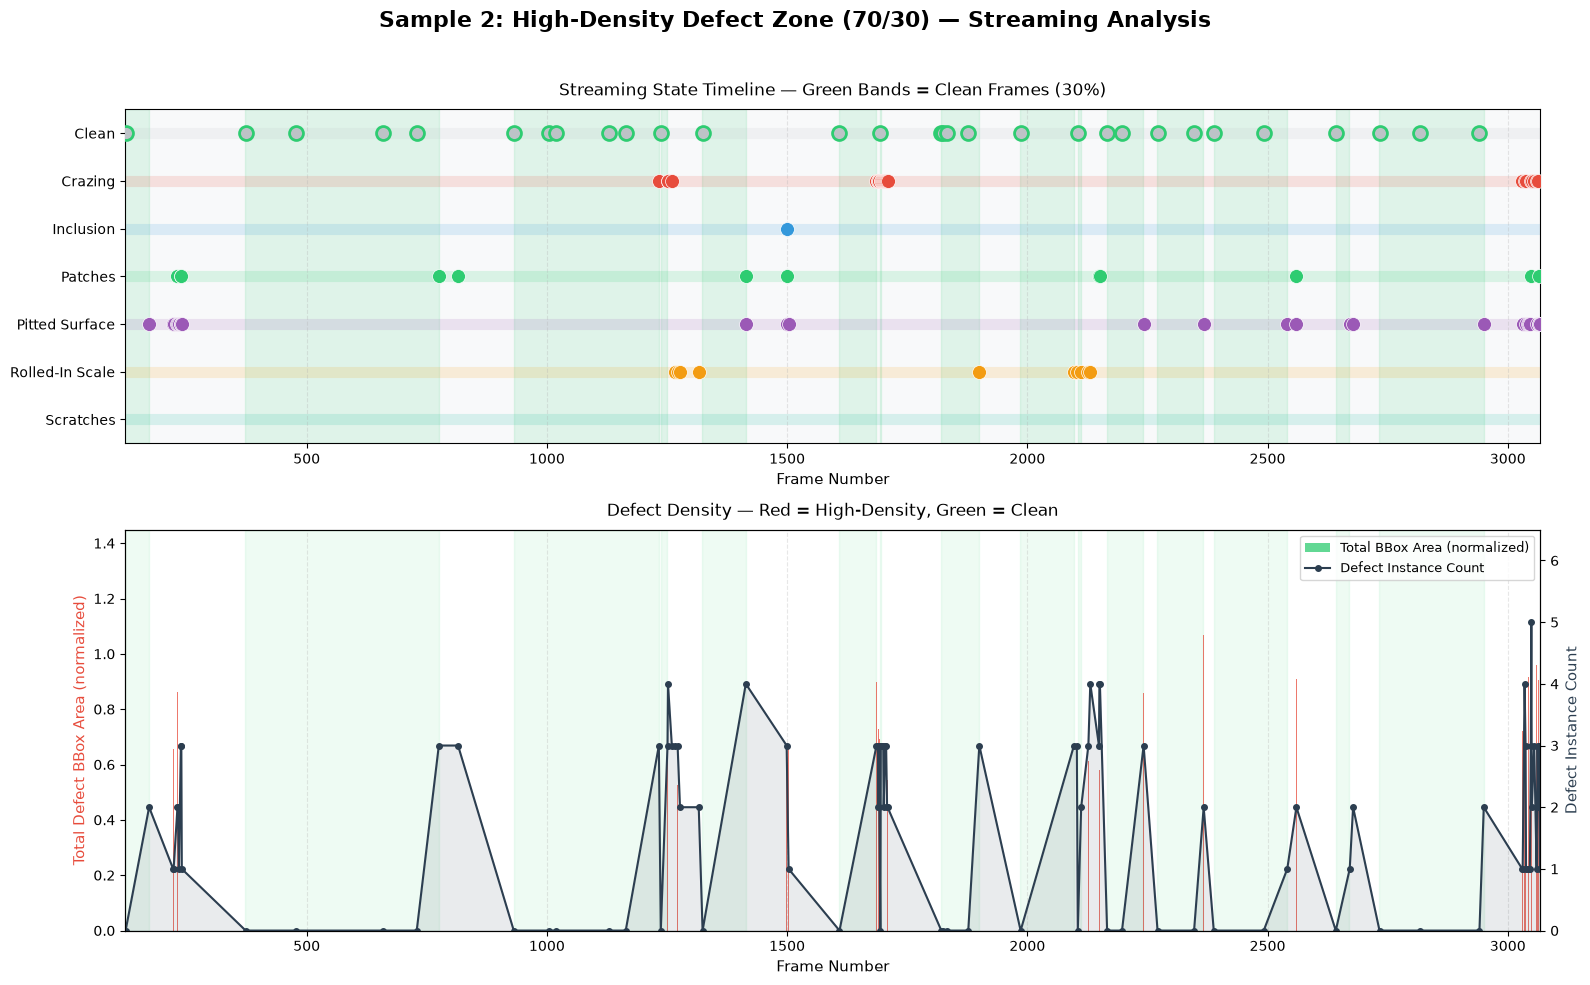

In [79]:
# config
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

SAMPLE_DIR = Path("sample_2_high_density")
SAMPLE_IMAGES = SAMPLE_DIR / "images" / "val"
SAMPLE_LABELS = SAMPLE_DIR / "labels" / "val"
OUTPUT_PLOT = Path("sample2_high_density_viz.png")

CLASS_NAMES = [
    "crazing", "inclusion", "patches", "pitted_surface",
    "rolled-in_scale", "scratches"
]
CLASS_COLORS = {
    "crazing": "#e74c3c",
    "inclusion": "#3498db",
    "patches": "#2ecc71",
    "pitted_surface": "#9b59b6",
    "rolled-in_scale": "#f39c12",
    "scratches": "#1abc9c",
    "clean": "#bdc3c7"
}
CLEAN_HIGHLIGHT = "#2ecc71"
DEFECT_HIGHLIGHT = "#e74c3c"

# read labels
def read_yolo_labels(label_path):
    if not label_path.exists():
        return []
    with open(label_path, "r") as f:
        lines = [line.strip() for line in f if line.strip()]
    entries = []
    for line in lines:
        parts = line.split()
        if len(parts) >= 5:
            cid = int(parts[0])
            bbox = [float(x) for x in parts[1:5]]
            entries.append((cid, bbox))
    return entries

def main():
    all_images = sorted([
        f for f in SAMPLE_IMAGES.iterdir()
        if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ], key=lambda p: int(p.stem.split("_")[0].replace("frame", "")))

    frames = []
    for idx, img_path in enumerate(all_images):
        stem = img_path.stem
        frame_num = int(stem.split("_")[0].replace("frame", ""))
        label_path = SAMPLE_LABELS / (stem + ".txt")
        entries = read_yolo_labels(label_path)

        defects = []
        total_area = 0.0
        for cid, bbox in entries:
            name = CLASS_NAMES[cid]
            area = bbox[2] * bbox[3]
            total_area += area
            defects.append(name)

        frames.append({
            "idx": idx,
            "num": frame_num,
            "name": img_path.name,
            "defects": defects,
            "total_area": total_area,
            "is_clean": len(defects) == 0
        })

    fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [1, 1.2]})
    fig.suptitle("Sample 2: High-Density Defect Zone (70/30) — Streaming Analysis",
                 fontsize=16, fontweight='bold')

    # timeline
    ax1 = axes[0]
    ax1.set_facecolor("#f8f9fa")

    y_positions = {"clean": 0}
    for i, name in enumerate(CLASS_NAMES):
        y_positions[name] = i + 1

    for frame in frames:
        x = frame["num"]
        if frame["is_clean"]:
            ax1.scatter(x, y_positions["clean"], c=CLASS_COLORS["clean"],
                       s=100, zorder=3, edgecolors=CLEAN_HIGHLIGHT, linewidth=2, marker='o')
        else:
            for d in set(frame["defects"]):
                ax1.scatter(x, y_positions[d], c=CLASS_COLORS[d],
                           s=100, zorder=3, edgecolors='white', linewidth=0.5, marker='o')

    for name, y in y_positions.items():
        ax1.axhline(y=y, color=CLASS_COLORS[name], alpha=0.15, linewidth=8, zorder=1)

    # highlight clean bands
    in_clean = False
    start = None
    for f in frames:
        if f["is_clean"] and not in_clean:
            start = f["num"]
            in_clean = True
        elif not f["is_clean"] and in_clean:
            ax1.axvspan(start - 0.5, f["num"] - 0.5, alpha=0.12, color=CLEAN_HIGHLIGHT, zorder=0)
            in_clean = False
    if in_clean:
        ax1.axvspan(start - 0.5, frames[-1]["num"] + 0.5, alpha=0.12, color=CLEAN_HIGHLIGHT, zorder=0)

    ax1.set_yticks(list(y_positions.values()))
    ax1.set_yticklabels([k.replace("_", " ").title() for k in y_positions.keys()])
    ax1.set_xlabel("Frame Number", fontsize=11)
    ax1.set_title("Streaming State Timeline — Green Bands = Clean Frames (30%)", fontsize=12, pad=10)
    ax1.set_xlim(frames[0]["num"] - 1, frames[-1]["num"] + 1)
    ax1.set_ylim(-0.5, len(y_positions) - 0.5)
    ax1.grid(axis='x', alpha=0.3, linestyle='--')
    ax1.invert_yaxis()

    # density
    ax2 = axes[1]

    x_vals = [f["num"] for f in frames]
    y_density = [f["total_area"] for f in frames]
    y_count = [len(f["defects"]) for f in frames]

    bar_colors = []
    for f in frames:
        if f["is_clean"]:
            bar_colors.append(CLEAN_HIGHLIGHT)
        else:
            bar_colors.append(DEFECT_HIGHLIGHT)

    bars = ax2.bar(x_vals, y_density, color=bar_colors, alpha=0.75, width=0.8,
                   label="Total BBox Area (normalized)")
    ax2_twin = ax2.twinx()
    ax2_twin.plot(x_vals, y_count, color="#2c3e50", marker='o', markersize=4,
                  linewidth=1.5, label="Defect Instance Count")
    ax2_twin.fill_between(x_vals, y_count, alpha=0.1, color="#2c3e50")

    # clean bands on density
    in_clean = False
    start = None
    for f in frames:
        if f["is_clean"] and not in_clean:
            start = f["num"]
            in_clean = True
        elif not f["is_clean"] and in_clean:
            ax2.axvspan(start - 0.5, f["num"] - 0.5, alpha=0.08, color=CLEAN_HIGHLIGHT, zorder=0)
            in_clean = False
    if in_clean:
        ax2.axvspan(start - 0.5, frames[-1]["num"] + 0.5, alpha=0.08, color=CLEAN_HIGHLIGHT, zorder=0)

    ax2.set_xlabel("Frame Number", fontsize=11)
    ax2.set_ylabel("Total Defect BBox Area (normalized)", fontsize=11, color="#e74c3c")
    ax2_twin.set_ylabel("Defect Instance Count", fontsize=11, color="#2c3e50")
    ax2.set_title("Defect Density — Red = High-Density, Green = Clean", fontsize=12, pad=10)
    ax2.set_xlim(frames[0]["num"] - 1, frames[-1]["num"] + 1)
    ax2.set_ylim(0, max(y_density) * 1.3 if max(y_density) > 0 else 1)
    ax2_twin.set_ylim(0, max(y_count) * 1.3 if max(y_count) > 0 else 1)
    ax2.grid(axis='x', alpha=0.3, linestyle='--')

    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2_twin.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(OUTPUT_PLOT, dpi=200, bbox_inches='tight', facecolor='white')
    print(f"Visualization saved to: {OUTPUT_PLOT.resolve()}")
    plt.show()

if __name__ == "__main__":
    main()

#### sample 3 change in production environment
1. Brightness reduced to 45–70% 
2. Contrast shifted by 0.65–1.35×.
3. Color saturation altered by 0.75–1.05× 
4. Sharpness reduced by 0.85–1.0×

In [80]:
OUTPUT_DIR = Path("sample_3_shift")
OUTPUT_IMAGES = OUTPUT_DIR / "images" / "val"
OUTPUT_LABELS = OUTPUT_DIR / "labels" / "val"

SAMPLE_SIZE = 100
TARGET_DEFECT_COUNT = 15
RANDOM_SEED = 42

CLASS_NAMES = [
    "crazing", "inclusion", "patches", "pitted_surface",
    "rolled-in_scale", "scratches"
]

random.seed(RANDOM_SEED)

# read labels
def read_yolo_labels(label_path):
    if not label_path.exists():
        return []
    with open(label_path, "r") as f:
        lines = [line.strip() for line in f if line.strip()]
    class_ids = set()
    for line in lines:
        parts = line.split()
        if len(parts) >= 5:
            class_ids.add(int(parts[0]))
    return sorted(class_ids)

def get_defect_classes_from_ids(class_ids):
    return [CLASS_NAMES[cid] for cid in class_ids if 0 <= cid < len(CLASS_NAMES)]

# transform
def apply_alloy_transform(img_path):
    img = Image.open(img_path).convert("RGB")
    
    brightness_factor = random.uniform(0.45, 0.70)
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(brightness_factor)
    
    contrast_factor = random.uniform(0.65, 1.35)
    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(contrast_factor)
    
    color_factor = random.uniform(0.75, 1.05)
    enhancer = ImageEnhance.Color(img)
    img = enhancer.enhance(color_factor)
    
    sharpness_factor = random.uniform(0.85, 1.0)
    enhancer = ImageEnhance.Sharpness(img)
    img = enhancer.enhance(sharpness_factor)
    
    return img

def main():
    all_images = sorted([
        f for f in SOURCE_IMAGES.iterdir()
        if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ])
    print(f"Found {len(all_images)} images in source.")

    # categorize
    clean_images = []
    defect_images = defaultdict(list)

    for img_path in all_images:
        label_path = SOURCE_LABELS / (img_path.stem + ".txt")
        cids = read_yolo_labels(label_path)
        classes = get_defect_classes_from_ids(cids)

        if not classes:
            clean_images.append(img_path)
        else:
            for c in classes:
                defect_images[c].append(img_path)

    # select defects
    selected_defect = set()
    
    for name in CLASS_NAMES:
        available = [img for img in defect_images[name] if img not in selected_defect]
        if available:
            selected_defect.add(random.choice(available))
    
    all_defect_pool = []
    for imgs in defect_images.values():
        for img in imgs:
            if img not in selected_defect:
                all_defect_pool.append(img)
    
    random.shuffle(all_defect_pool)
    remaining_defect = TARGET_DEFECT_COUNT - len(selected_defect)
    if remaining_defect > 0:
        selected_defect.update(all_defect_pool[:remaining_defect])
    
    # select clean
    random.shuffle(clean_images)
    selected_clean = set(clean_images[:85])
    
    # combine
    final_selection = sorted(
        list(selected_defect | selected_clean),
        key=lambda p: int(p.stem.split("_")[0].replace("frame", ""))
    )

    # report before transform
    dist_counter = Counter()
    for img_path in final_selection:
        label_path = SOURCE_LABELS / (img_path.stem + ".txt")
        cids = read_yolo_labels(label_path)
        classes = get_defect_classes_from_ids(cids)
        if not classes:
            dist_counter["clean"] += 1
        else:
            for c in classes:
                dist_counter[c] += 1

    print(f"\nSelected {len(final_selection)} images for transformation.")
    print(f"  Clean: {dist_counter['clean']}")
    print(f"  Defective: {len(final_selection) - dist_counter['clean']}")
    for name in CLASS_NAMES:
        print(f"  {name}: {dist_counter.get(name, 0)}")

    # create dirs and transform
    OUTPUT_IMAGES.mkdir(parents=True, exist_ok=True)
    OUTPUT_LABELS.mkdir(parents=True, exist_ok=True)

    for img_path in final_selection:
        stem = img_path.stem
        
        transformed = apply_alloy_transform(img_path)
        out_img_path = OUTPUT_IMAGES / img_path.name
        transformed.save(out_img_path, quality=95)
        
        label_path = SOURCE_LABELS / (stem + ".txt")
        out_label_path = OUTPUT_LABELS / (stem + ".txt")
        if label_path.exists():
            shutil.copy2(label_path, out_label_path)
        else:
            out_label_path.touch()

    print(f"\nSample 3 created at: {OUTPUT_DIR.resolve()}")
    print("Applied transforms per image:")
    print("  - Brightness: 45%–70%")
    print("  - Contrast: 65%–135%")
    print("  - Color: 75%–105%")
    print("  - Sharpness: 85%–100%")

if __name__ == "__main__":
    main()

Found 3072 images in source.

Selected 100 images for transformation.
  Clean: 85
  Defective: 15
  crazing: 4
  inclusion: 1
  patches: 4
  pitted_surface: 3
  rolled-in_scale: 2
  scratches: 2

Sample 3 created at: C:\Users\acer\Desktop\DataAugmentation\sample_3_shift
Applied transforms per image:
  - Brightness: 45%–70%
  - Contrast: 65%–135%
  - Color: 75%–105%
  - Sharpness: 85%–100%


Visualization saved to: C:\Users\acer\Desktop\DataAugmentation\sample3_shift_viz.png


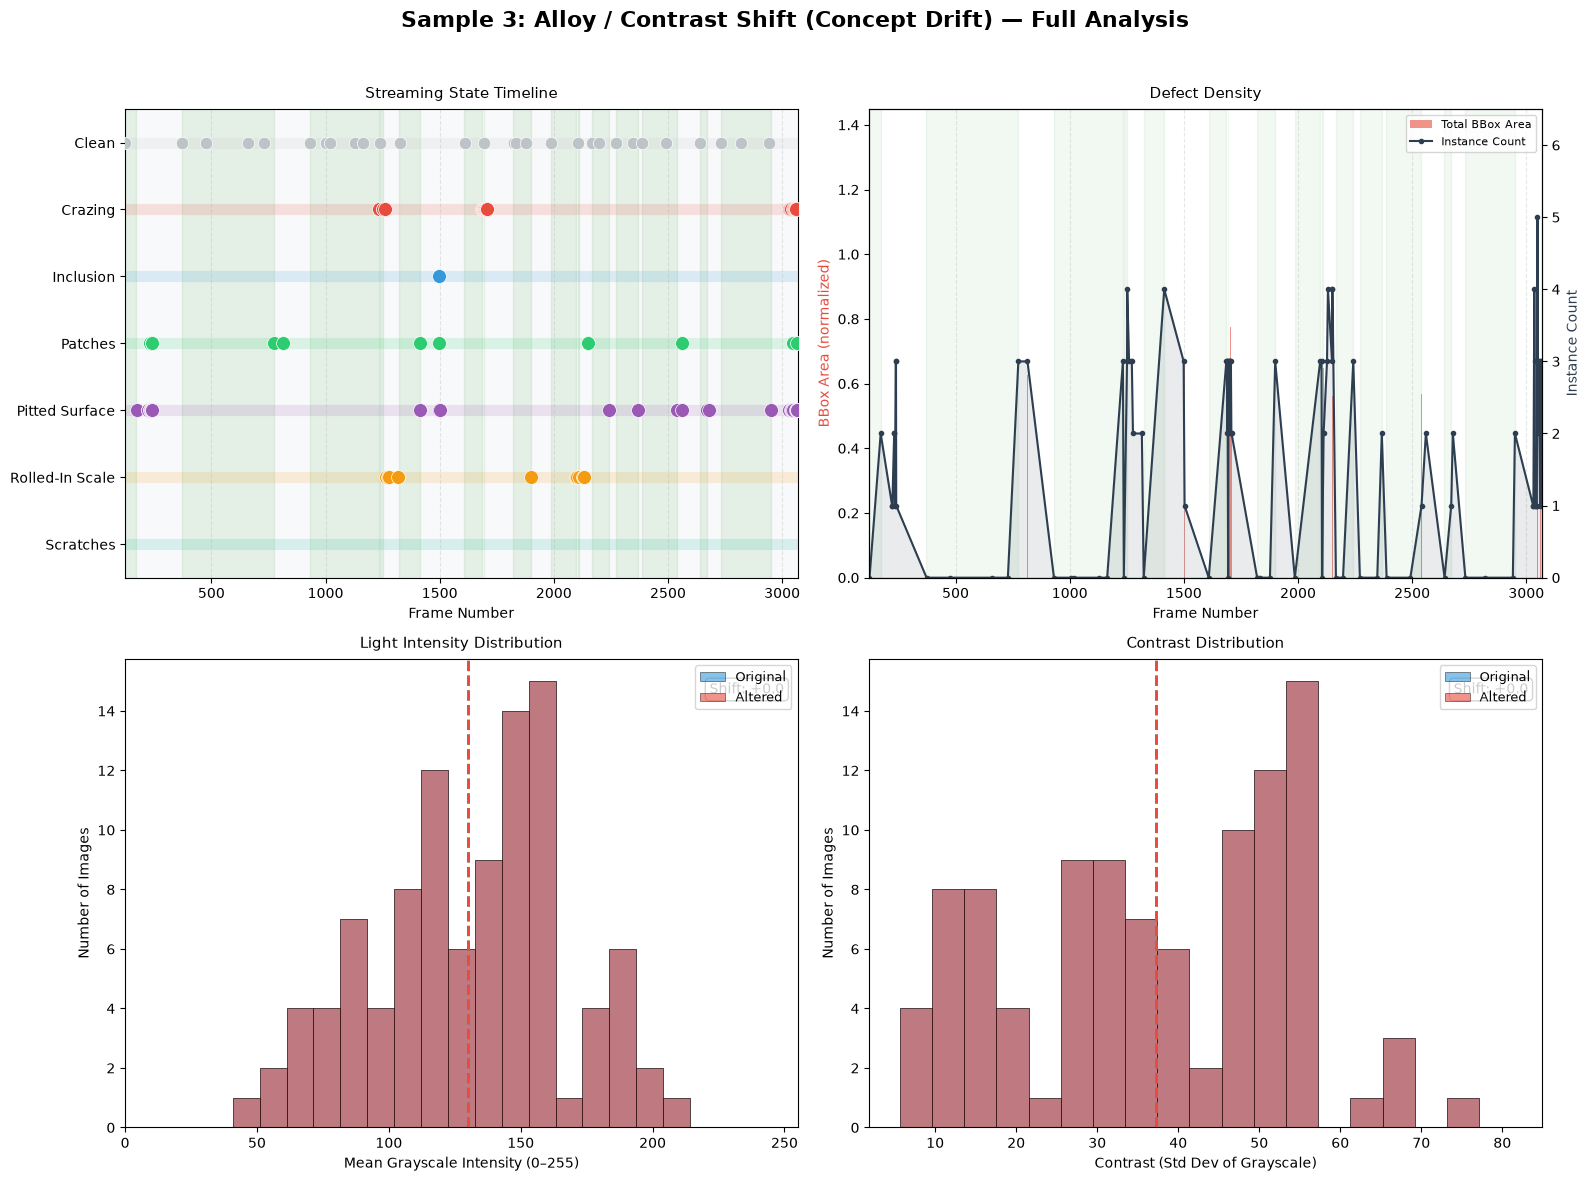

In [81]:
OUTPUT_PLOT = Path("sample3_shift_viz.png")

CLASS_NAMES = [
    "crazing", "inclusion", "patches", "pitted_surface",
    "rolled-in_scale", "scratches"
]
CLASS_COLORS = {
    "crazing": "#e74c3c",
    "inclusion": "#3498db",
    "patches": "#2ecc71",
    "pitted_surface": "#9b59b6",
    "rolled-in_scale": "#f39c12",
    "scratches": "#1abc9c",
    "clean": "#bdc3c7"
}

# read labels
def read_yolo_labels(label_path):
    if not label_path.exists():
        return []
    with open(label_path, "r") as f:
        lines = [line.strip() for line in f if line.strip()]
    entries = []
    for line in lines:
        parts = line.split()
        if len(parts) >= 5:
            cid = int(parts[0])
            bbox = [float(x) for x in parts[1:5]]
            entries.append((cid, bbox))
    return entries

def main():
    all_images = sorted([
        f for f in SAMPLE_IMAGES.iterdir()
        if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ], key=lambda p: int(p.stem.split("_")[0].replace("frame", "")))

    # stats
    original_means = []
    original_stds = []
    altered_means = []
    altered_stds = []

    frames = []
    for idx, img_path in enumerate(all_images):
        stem = img_path.stem
        frame_num = int(stem.split("_")[0].replace("frame", ""))

        altered_img = Image.open(img_path).convert("L")
        altered_arr = np.array(altered_img)
        altered_means.append(np.mean(altered_arr))
        altered_stds.append(np.std(altered_arr))

        orig_path = SOURCE_IMAGES / img_path.name
        if orig_path.exists():
            orig_img = Image.open(orig_path).convert("L")
            orig_arr = np.array(orig_img)
            original_means.append(np.mean(orig_arr))
            original_stds.append(np.std(orig_arr))

        label_path = SAMPLE_LABELS / (stem + ".txt")
        entries = read_yolo_labels(label_path)

        defects = []
        total_area = 0.0
        for cid, bbox in entries:
            name = CLASS_NAMES[cid]
            area = bbox[2] * bbox[3]
            total_area += area
            defects.append(name)

        frames.append({
            "idx": idx,
            "num": frame_num,
            "defects": defects,
            "total_area": total_area,
            "is_clean": len(defects) == 0
        })

    # figure
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle("Sample 3: Alloy / Contrast Shift (Concept Drift) — Full Analysis",
                 fontsize=16, fontweight='bold')

    # panel 1: timeline
    ax1 = axes[0, 0]
    ax1.set_facecolor("#f8f9fa")

    y_positions = {"clean": 0}
    for i, name in enumerate(CLASS_NAMES):
        y_positions[name] = i + 1

    for frame in frames:
        x = frame["num"]
        if frame["is_clean"]:
            ax1.scatter(x, y_positions["clean"], c=CLASS_COLORS["clean"],
                       s=80, zorder=3, edgecolors='white', linewidth=0.5)
        else:
            for d in set(frame["defects"]):
                ax1.scatter(x, y_positions[d], c=CLASS_COLORS[d],
                           s=100, zorder=3, edgecolors='white', linewidth=0.5, marker='o')

    for name, y in y_positions.items():
        ax1.axhline(y=y, color=CLASS_COLORS[name], alpha=0.15, linewidth=8, zorder=1)

    ax1.set_yticks(list(y_positions.values()))
    ax1.set_yticklabels([k.replace("_", " ").title() for k in y_positions.keys()])
    ax1.set_xlabel("Frame Number", fontsize=10)
    ax1.set_title("Streaming State Timeline", fontsize=11, pad=8)
    ax1.set_xlim(frames[0]["num"] - 1, frames[-1]["num"] + 1)
    ax1.set_ylim(-0.5, len(y_positions) - 0.5)
    ax1.grid(axis='x', alpha=0.3, linestyle='--')
    ax1.invert_yaxis()

    # panel 2: density
    ax2 = axes[0, 1]

    x_vals = [f["num"] for f in frames]
    y_density = [f["total_area"] for f in frames]
    y_count = [len(f["defects"]) for f in frames]

    bars = ax2.bar(x_vals, y_density, color="#e74c3c", alpha=0.6, width=0.8,
                   label="Total BBox Area")
    ax2_twin = ax2.twinx()
    ax2_twin.plot(x_vals, y_count, color="#2c3e50", marker='o', markersize=3,
                  linewidth=1.5, label="Instance Count")
    ax2_twin.fill_between(x_vals, y_count, alpha=0.1, color="#2c3e50")

    ax2.set_xlabel("Frame Number", fontsize=10)
    ax2.set_ylabel("BBox Area (normalized)", fontsize=10, color="#e74c3c")
    ax2_twin.set_ylabel("Instance Count", fontsize=10, color="#2c3e50")
    ax2.set_title("Defect Density", fontsize=11, pad=8)
    ax2.set_xlim(frames[0]["num"] - 1, frames[-1]["num"] + 1)
    ax2.set_ylim(0, max(y_density) * 1.3 if max(y_density) > 0 else 1)
    ax2_twin.set_ylim(0, max(y_count) * 1.3 if max(y_count) > 0 else 1)
    ax2.grid(axis='x', alpha=0.3, linestyle='--')

    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2_twin.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)

    # clean shading
    in_clean = False
    start = None
    for f in frames:
        if f["is_clean"] and not in_clean:
            start = f["num"]
            in_clean = True
        elif not f["is_clean"] and in_clean:
            ax1.axvspan(start - 0.4, f["num"] - 0.4, alpha=0.08, color='green', zorder=0)
            ax2.axvspan(start - 0.4, f["num"] - 0.4, alpha=0.05, color='green', zorder=0)
            in_clean = False
    if in_clean:
        ax1.axvspan(start - 0.4, frames[-1]["num"] + 0.4, alpha=0.08, color='green', zorder=0)
        ax2.axvspan(start - 0.4, frames[-1]["num"] + 0.4, alpha=0.05, color='green', zorder=0)

    # panel 3: mean intensity
    ax3 = axes[1, 0]

    bins = np.linspace(0, 255, 26)

    ax3.hist(original_means, bins=bins, alpha=0.6, color="#3498db",
             edgecolor="black", linewidth=0.5, label="Original")
    ax3.hist(altered_means, bins=bins, alpha=0.6, color="#e74c3c",
             edgecolor="black", linewidth=0.5, label="Altered")

    ax3.axvline(np.mean(original_means), color="#3498db", linestyle="--", linewidth=2)
    ax3.axvline(np.mean(altered_means), color="#e74c3c", linestyle="--", linewidth=2)

    ax3.set_xlabel("Mean Grayscale Intensity (0–255)", fontsize=10)
    ax3.set_ylabel("Number of Images", fontsize=10)
    ax3.set_title("Light Intensity Distribution", fontsize=11, pad=8)
    ax3.legend(loc='upper right', fontsize=9)
    ax3.set_xlim(0, 255)

    shift = np.mean(altered_means) - np.mean(original_means)
    ax3.text(0.98, 0.95, f"Shift: {shift:+.1f}",
             transform=ax3.transAxes, fontsize=10, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # panel 4: contrast
    ax4 = axes[1, 1]

    all_stds = original_stds + altered_stds
    bin_min, bin_max = min(all_stds) * 0.9, max(all_stds) * 1.1
    bins_std = np.linspace(bin_min, bin_max, 20)

    ax4.hist(original_stds, bins=bins_std, alpha=0.6, color="#3498db",
             edgecolor="black", linewidth=0.5, label="Original")
    ax4.hist(altered_stds, bins=bins_std, alpha=0.6, color="#e74c3c",
             edgecolor="black", linewidth=0.5, label="Altered")

    ax4.axvline(np.mean(original_stds), color="#3498db", linestyle="--", linewidth=2)
    ax4.axvline(np.mean(altered_stds), color="#e74c3c", linestyle="--", linewidth=2)

    ax4.set_xlabel("Contrast (Std Dev of Grayscale)", fontsize=10)
    ax4.set_ylabel("Number of Images", fontsize=10)
    ax4.set_title("Contrast Distribution", fontsize=11, pad=8)
    ax4.legend(loc='upper right', fontsize=9)

    shift_std = np.mean(altered_stds) - np.mean(original_stds)
    ax4.text(0.98, 0.95, f"Shift: {shift_std:+.1f}",
             transform=ax4.transAxes, fontsize=10, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(OUTPUT_PLOT, dpi=200, bbox_inches='tight', facecolor='white')
    print(f"Visualization saved to: {OUTPUT_PLOT.resolve()}")
    plt.show()

if __name__ == "__main__":
    main()